# 03 — Análisis completo de Fronteras (S1–S3)

Este cuaderno completa el **Bloque B de la Parte II** para las tres fronteras
con mayor acumulado de turistas y excursionistas: La Aurora, Valle Nuevo y San
Cristóbal. Cada serie sigue el mismo flujo: inspección, descomposición aditiva
y multiplicativa, estacionariedad en varianza y media, ACF/PACF, candidatos
ARIMA/SARIMA, cuatro modelos alternativos, residuos y pronóstico de los 63
meses de prueba.

## Metodología común

- Frecuencia mensual (`MS`) y período estacional 12.
- Entrenamiento: enero de 2009 a marzo de 2021 (147 meses).
- Prueba: abril de 2021 a junio de 2026 (63 meses), sin barajar.
- La elección de `d` y `D` usa ADF, KPSS y ACF.
- ACF/PACF se muestran por separado después de `d=1` y después de
  `d=1,D=1`, para no mezclar la selección regular con la estacional.
- Los residuos se revisan con serie temporal, ACF, Ljung-Box, histograma,
  Jarque-Bera y gráfico Q-Q.
- El mejor pronóstico se selecciona principalmente por RMSE en prueba, sin
  ignorar AIC/BIC ni el diagnóstico residual.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from modelado_s1_s2_s6 import ejecutar_modelado_fronteras

resultados, comparativo = ejecutar_modelado_fronteras(
    guardar=True,
    generar_figuras=True,
)
DIR_RESULTADOS = RAIZ / "data" / "processed" / "resultados"
DIR_IMG = RAIZ / "informe" / "img" / "final"
metricas = pd.read_csv(DIR_RESULTADOS / "metricas_fronteras.csv")
estacionariedad = pd.read_csv(
    DIR_RESULTADOS / "estacionariedad_fronteras.csv"
)

validacion = pd.DataFrame({
    "serie": ["S1", "S2", "S3"],
    "meses_total": [len(resultados[n]["serie"]) for n in resultados],
    "meses_train": [len(resultados[n]["train"]) for n in resultados],
    "meses_test": [len(resultados[n]["test"]) for n in resultados],
    "ceros_train": [
        resultados[n]["resumen"]["ceros_train"] for n in resultados
    ],
    "ceros_test": [
        resultados[n]["resumen"]["ceros_test"] for n in resultados
    ],
})
validacion

09:53:43 - cmdstanpy - INFO - Chain [1] start processing


09:53:43 - cmdstanpy - INFO - Chain [1] done processing


09:53:46 - cmdstanpy - INFO - Chain [1] start processing


09:53:46 - cmdstanpy - INFO - Chain [1] done processing


09:53:51 - cmdstanpy - INFO - Chain [1] start processing


09:53:51 - cmdstanpy - INFO - Chain [1] done processing


,serie,meses_total,meses_train,meses_test,ceros_train,ceros_test
0,S1,210,147,63,0,0
1,S2,210,147,63,0,0
2,S3,210,147,63,0,0


## S1 — La Aurora

La Aurora es la frontera aérea principal. Su fuerza estacional es 0.559 y la
de tendencia 0.811. La correlación media-desviación prepandemia baja de 0.889
en nivel a -0.209 después del logaritmo, por lo que la transformación elimina
la relación positiva entre nivel y amplitud. La forma multiplicativa es la
descomposición descriptiva preferida.

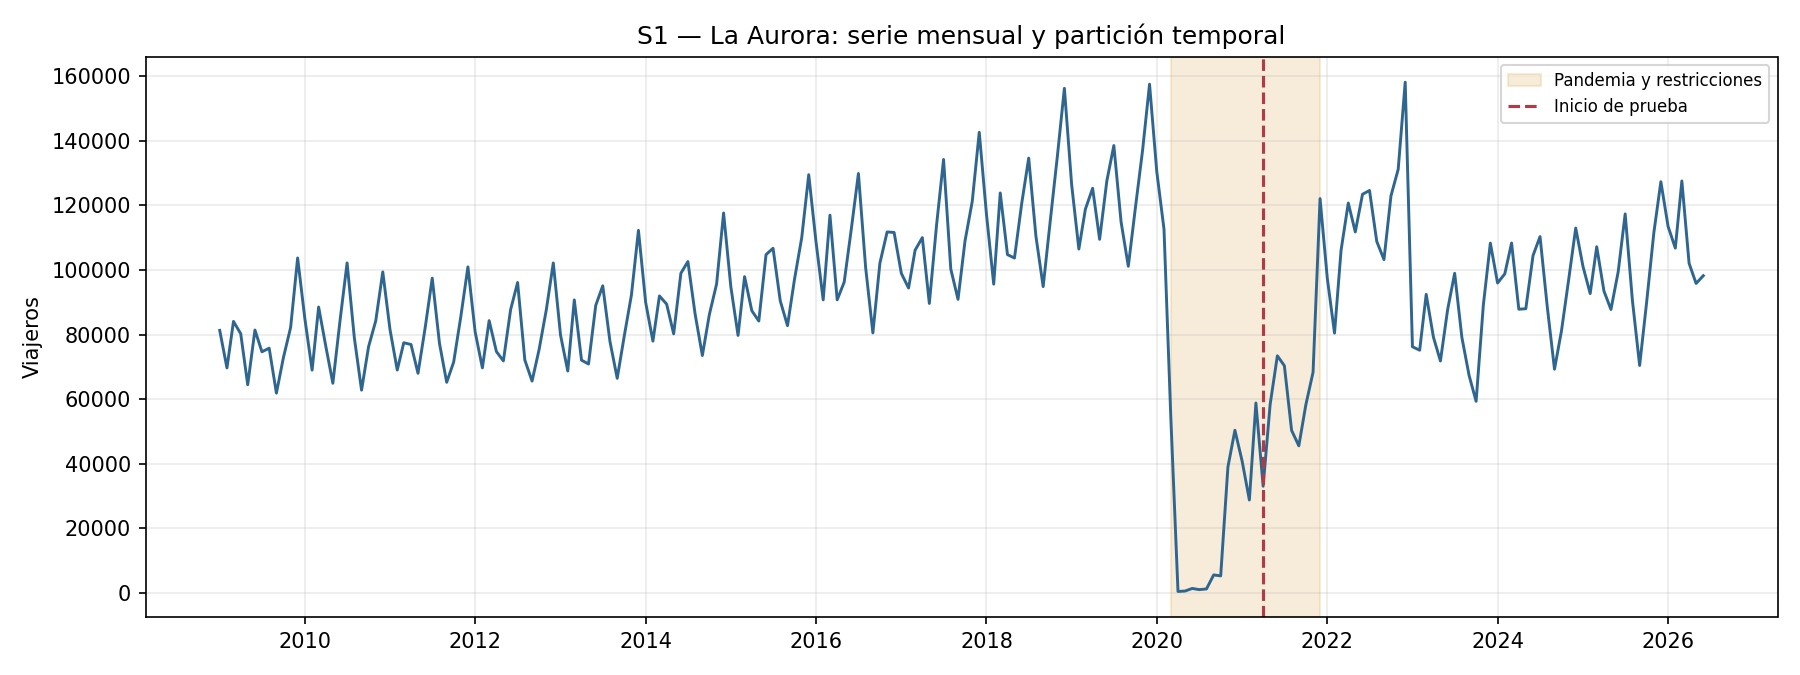

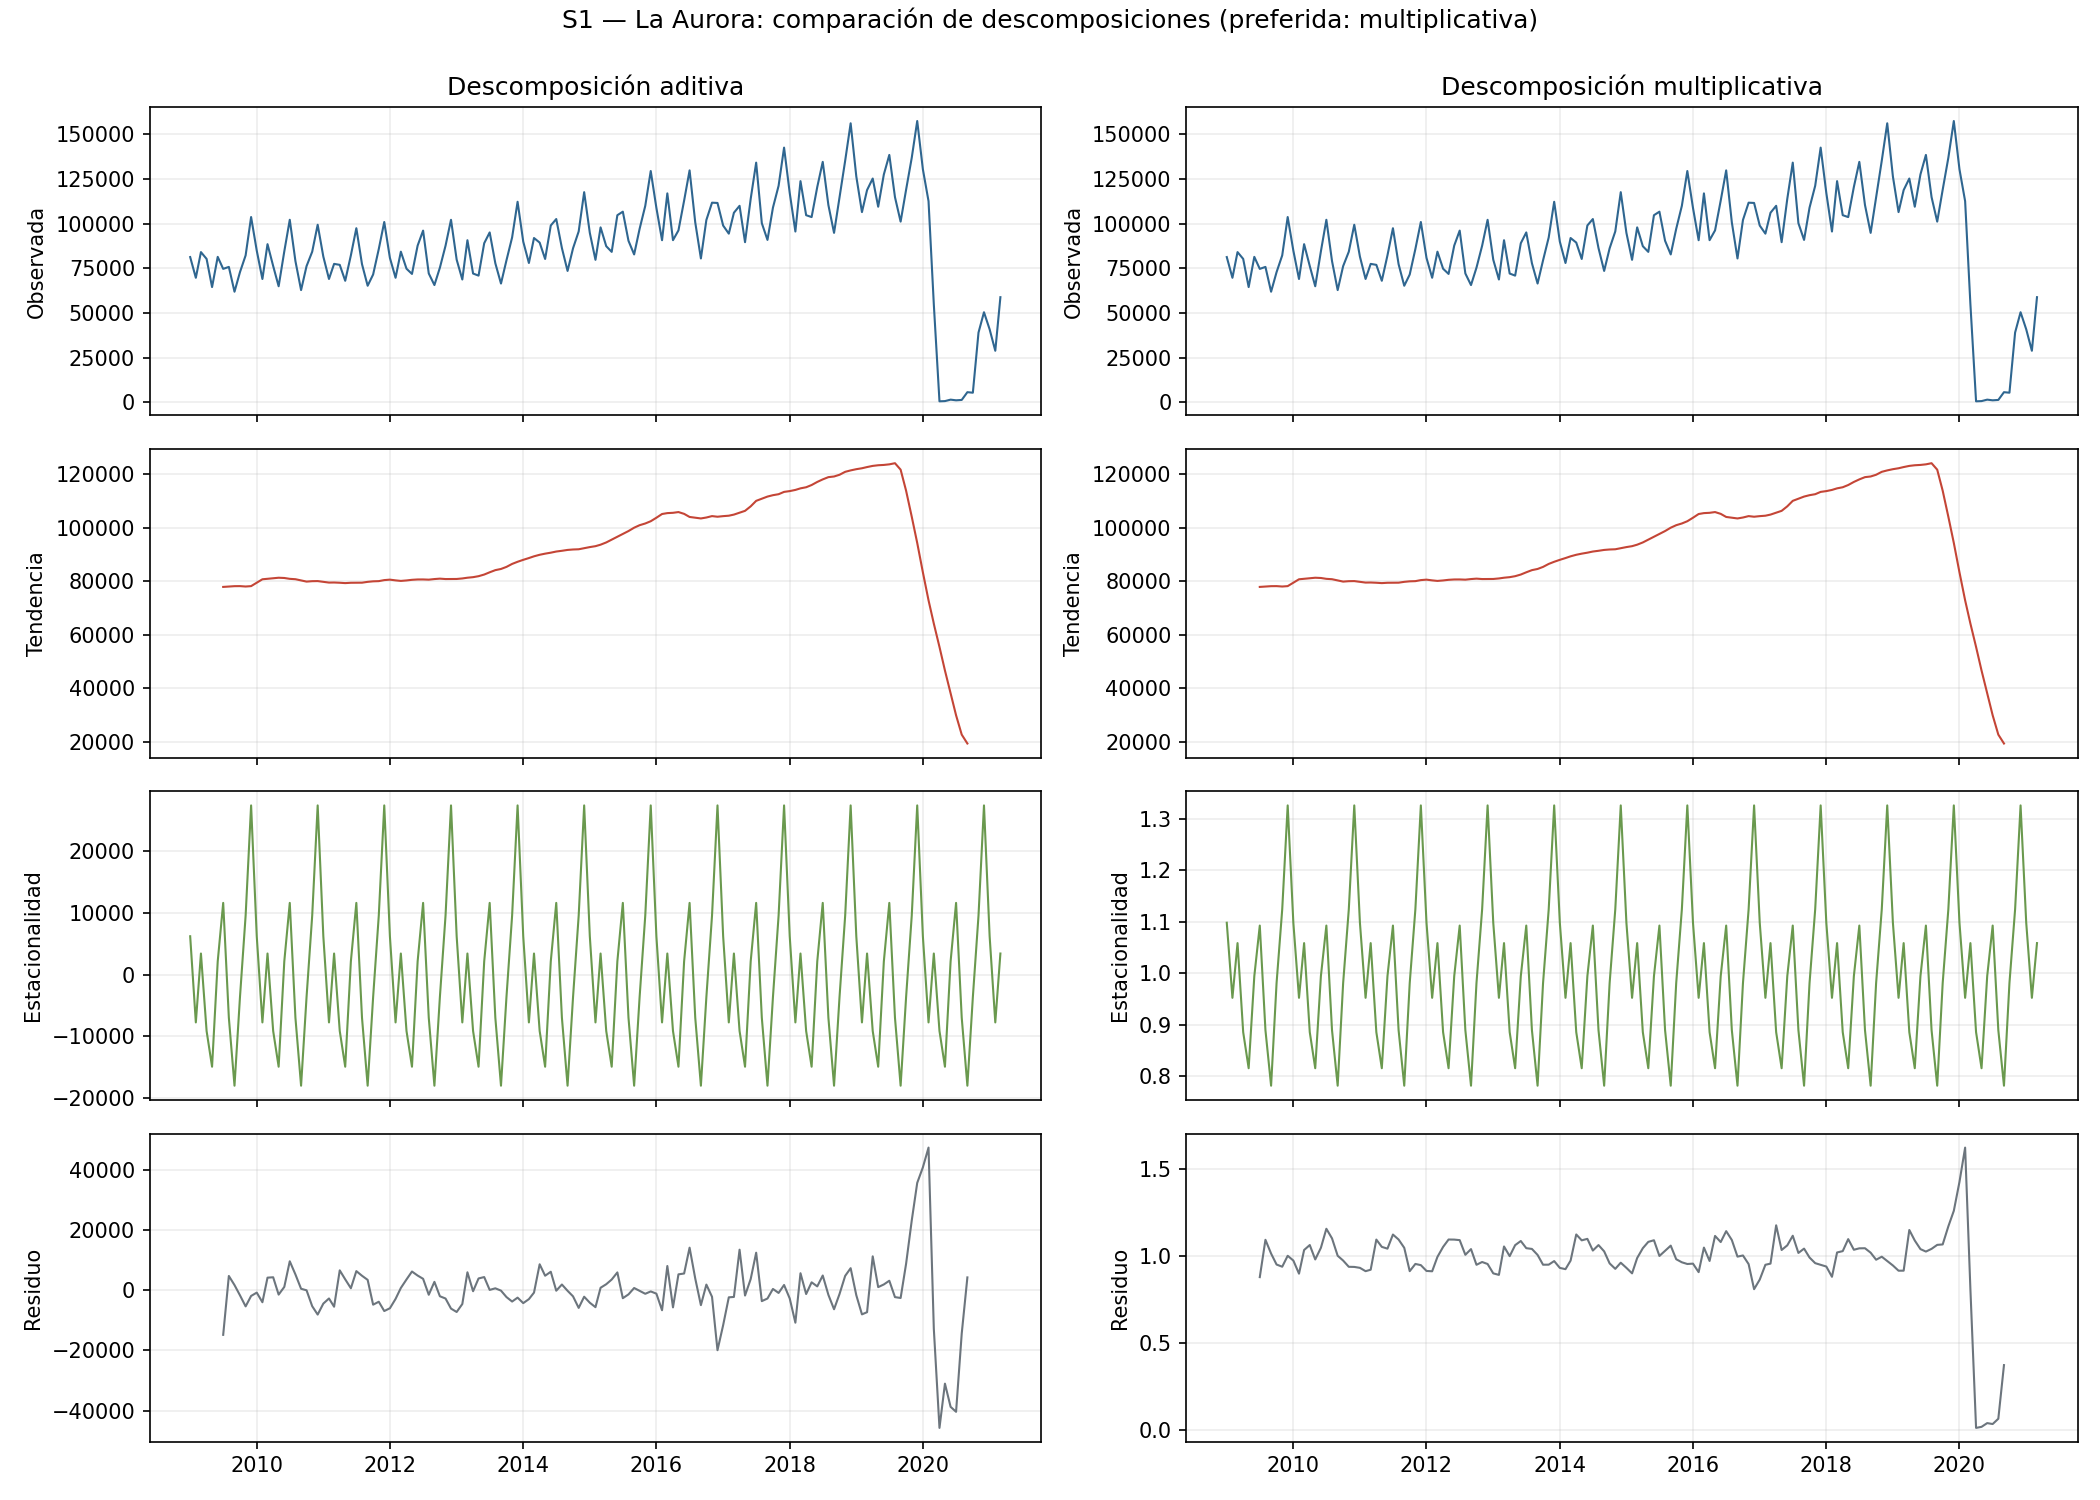

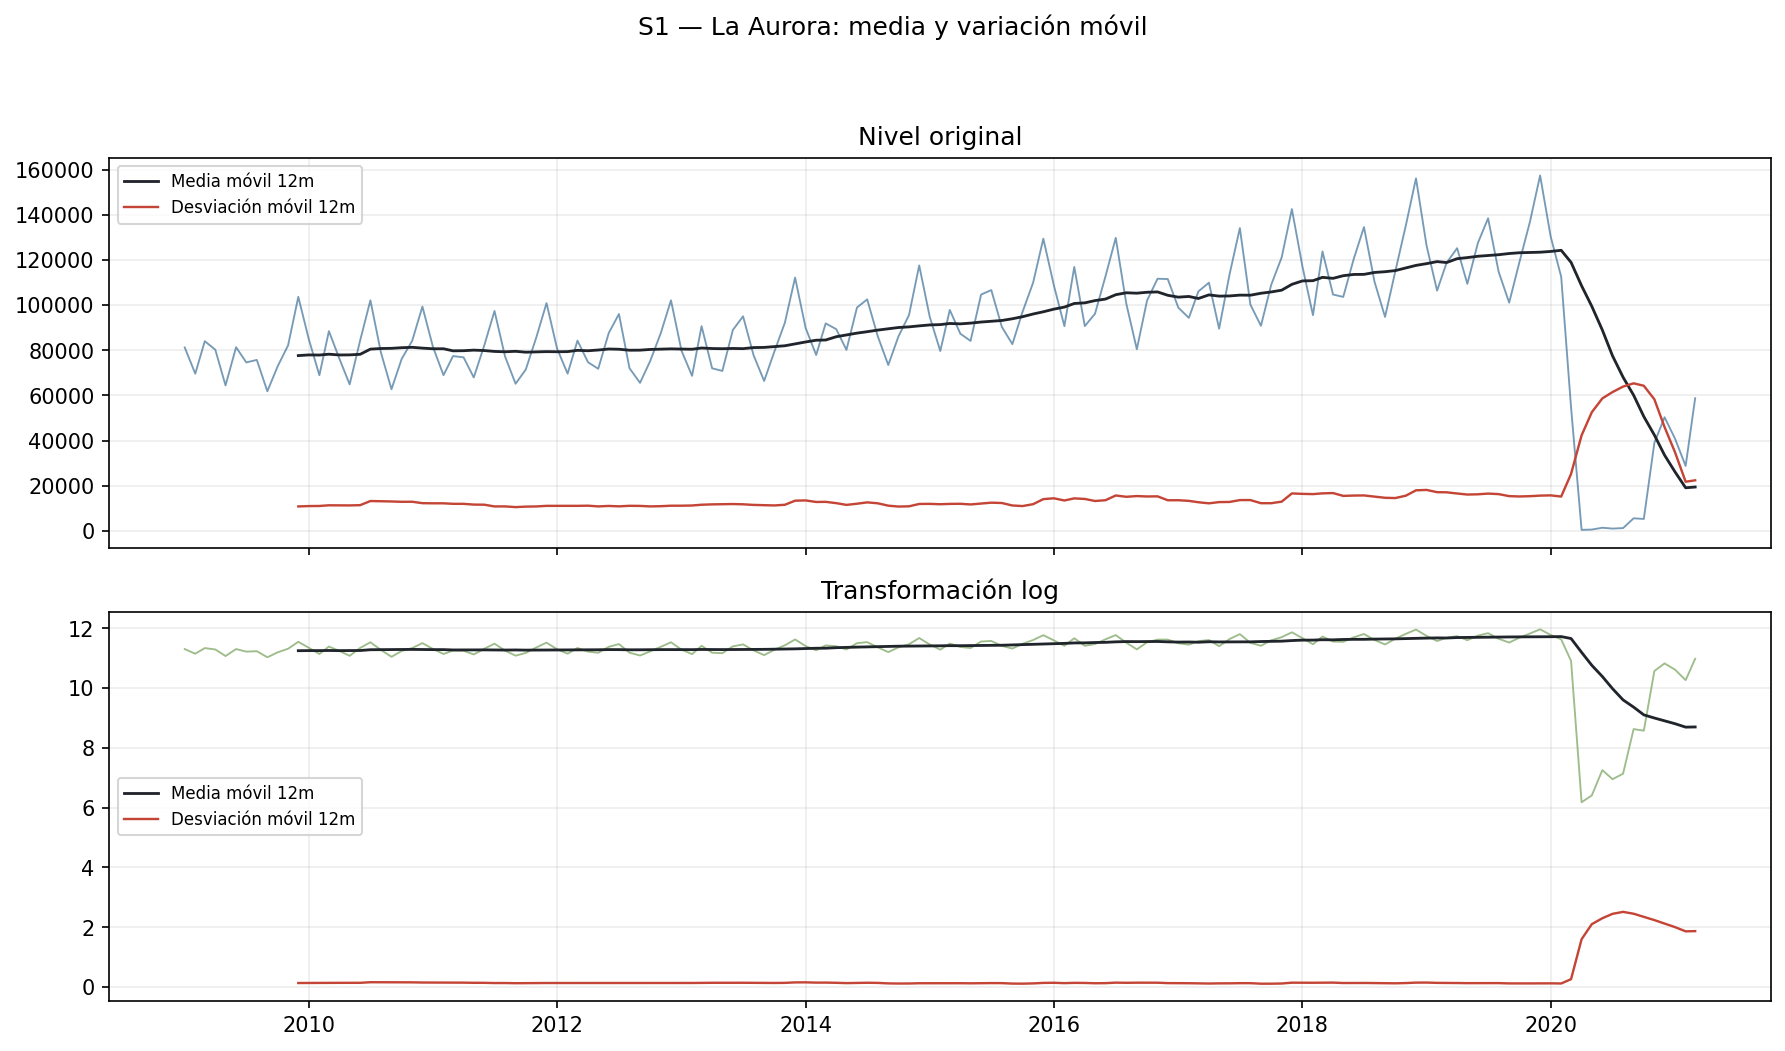

In [2]:
display(Image(filename=str(DIR_IMG / "s1_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s1_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s1_varianza.png")))

ADF y KPSS coinciden en estacionariedad después de `d=1`. ACF y PACF no
muestran un corte limpio en el primer rezago y conservan picos aislados en 5 y
7 por el choque pandémico. Se comparan órdenes bajos `(1,1,0)`, `(0,1,1)` y
`(1,1,1)`, además de un SARIMA anual.

,transformacion,p_ADF,p_KPSS,veredicto
0,Nivel,0.1505,0.100,"resultado mixto: KPSS dice estacionaria, ADF no"
1,log,0.2726,0.100,"resultado mixto: KPSS dice estacionaria, ADF no"
2,log + d=1,0.0269,0.100,estacionaria (ambas pruebas coinciden)
3,log + D=1,0.8311,0.044,NO estacionaria (ambas pruebas coinciden)
4,log + d=1 + D=1,0.0000,0.100,estacionaria (ambas pruebas coinciden)


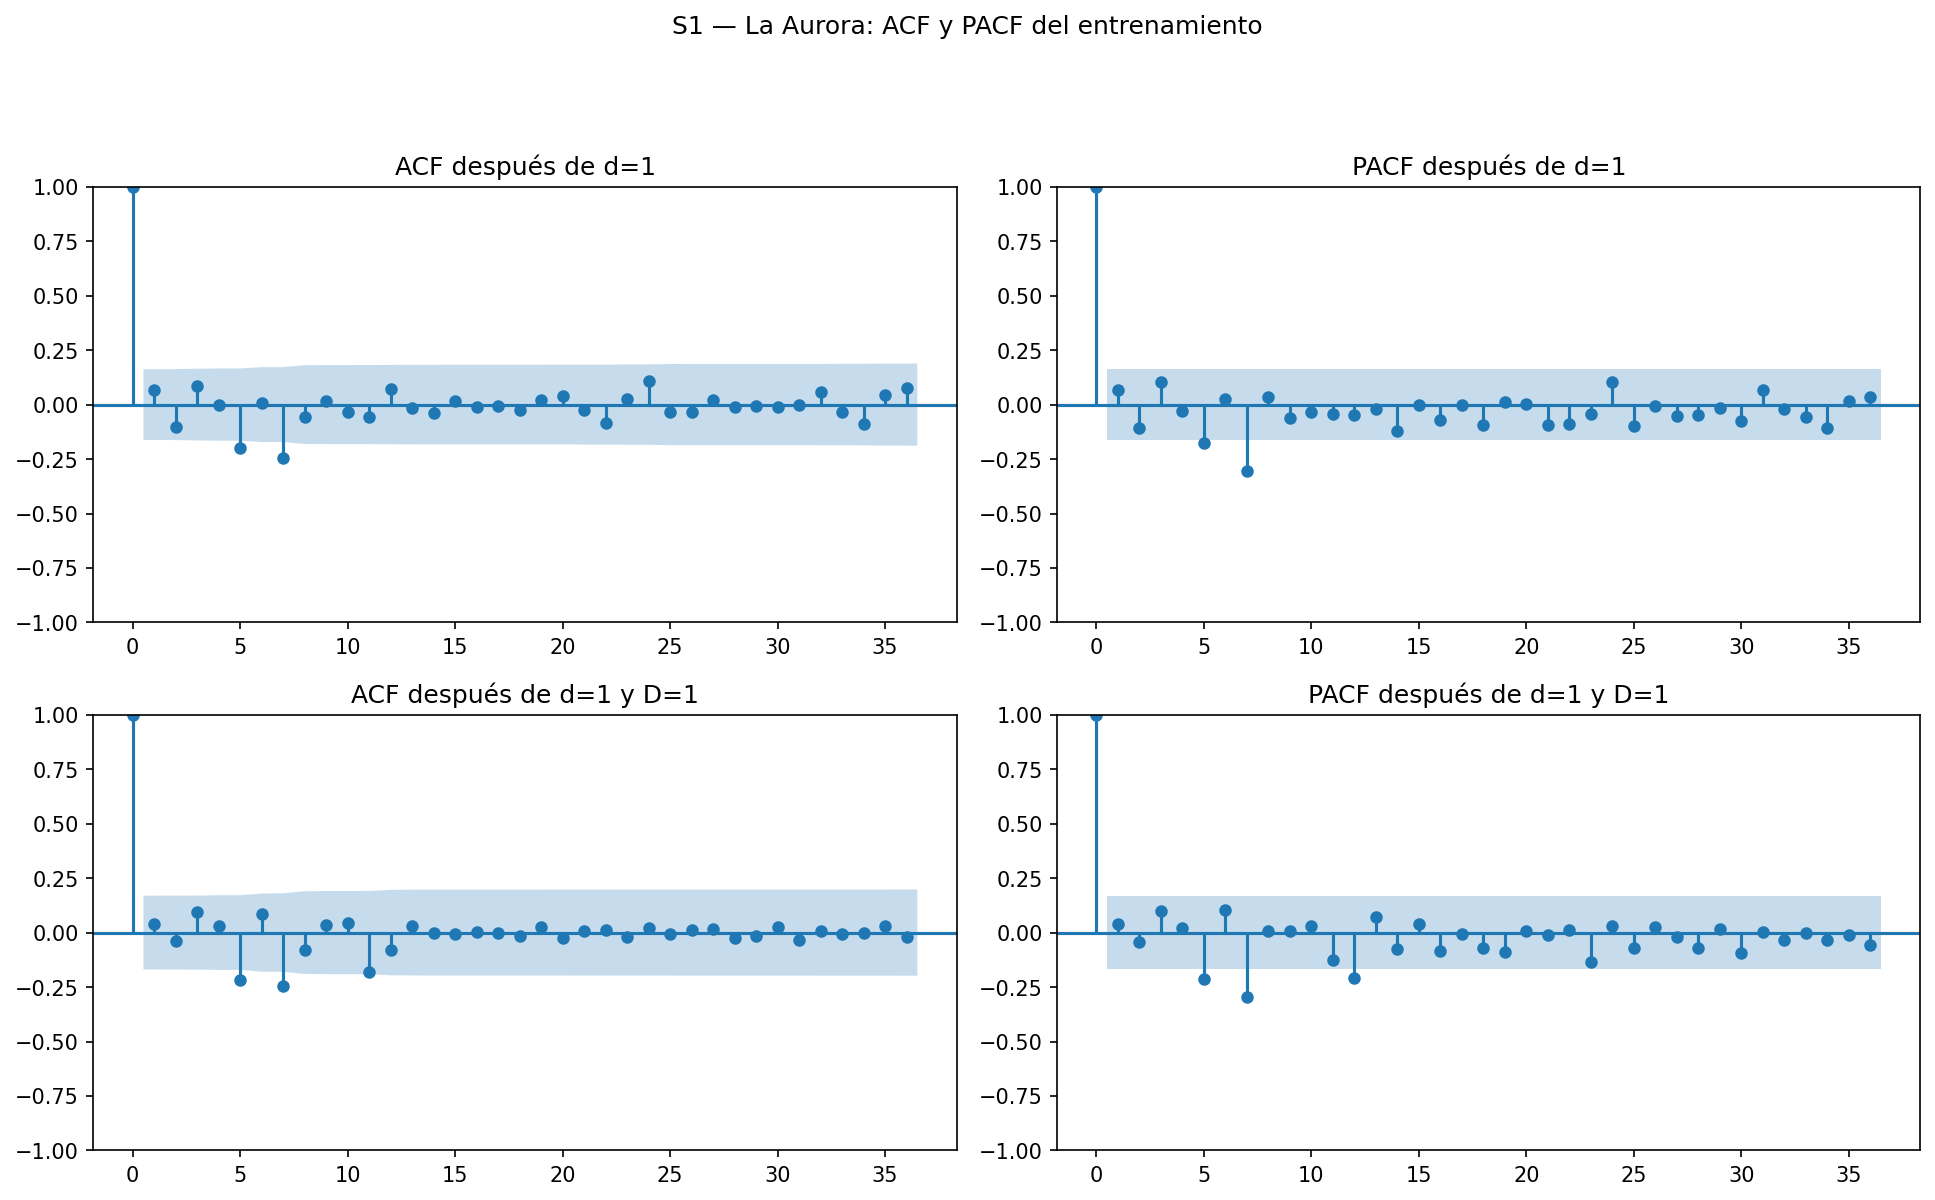

In [3]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S1_la_aurora",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s1_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,"ARIMA(1,1,1)",207.0270,215.9365,33049.4175,38249.0739,33.0811,0.0745,0.000,True
1,"ARIMA(0,1,1)",206.0727,212.0123,33467.5012,38659.1315,33.4211,0.0613,0.000,False
2,"ARIMA(1,1,0)",206.8474,212.8009,34250.3866,39443.8959,34.1441,0.0606,0.000,False
3,Suavizamiento exponencial simple,NaN,NaN,36821.7860,42053.3179,36.5631,0.0000,0.073,False
4,Holt-Winters,NaN,NaN,38903.9061,42886.6863,39.4921,0.2645,0.000,False
5,Prophet,NaN,NaN,45973.0569,50962.9280,47.4748,0.0000,0.000,False
6,"SARIMA(1,1,1)(0,1,1,12)",187.1072,198.2572,68210.1587,72421.3103,71.9935,0.0302,0.000,False
7,"auto_arima(1, 0, 1)x(1, 0, 1, 12)",189.5742,204.0260,71902.8836,75900.7438,76.2893,0.0317,0.000,False
8,Seasonal Naive,NaN,NaN,75518.4404,79320.7597,81.4775,0.0000,0.000,False


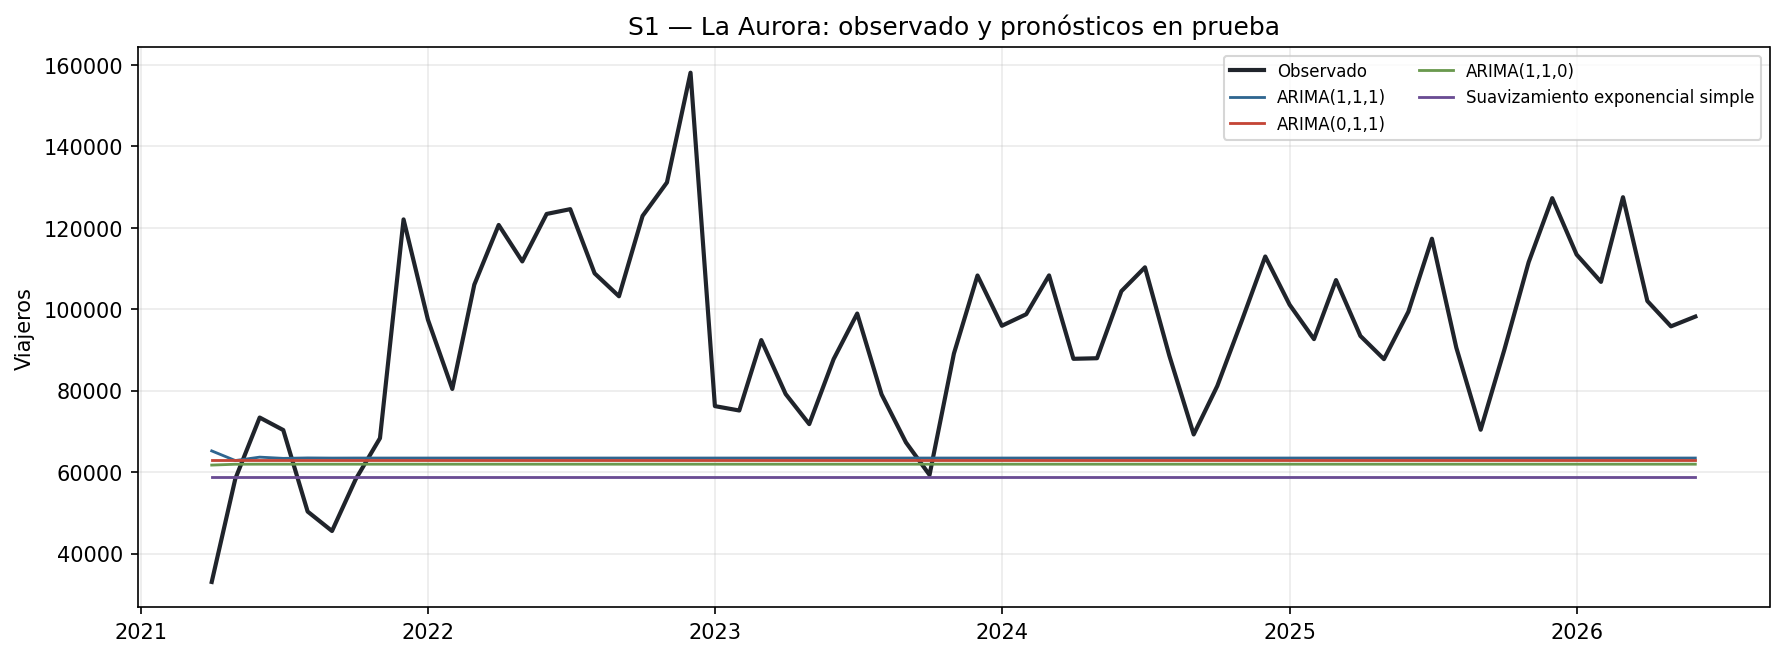

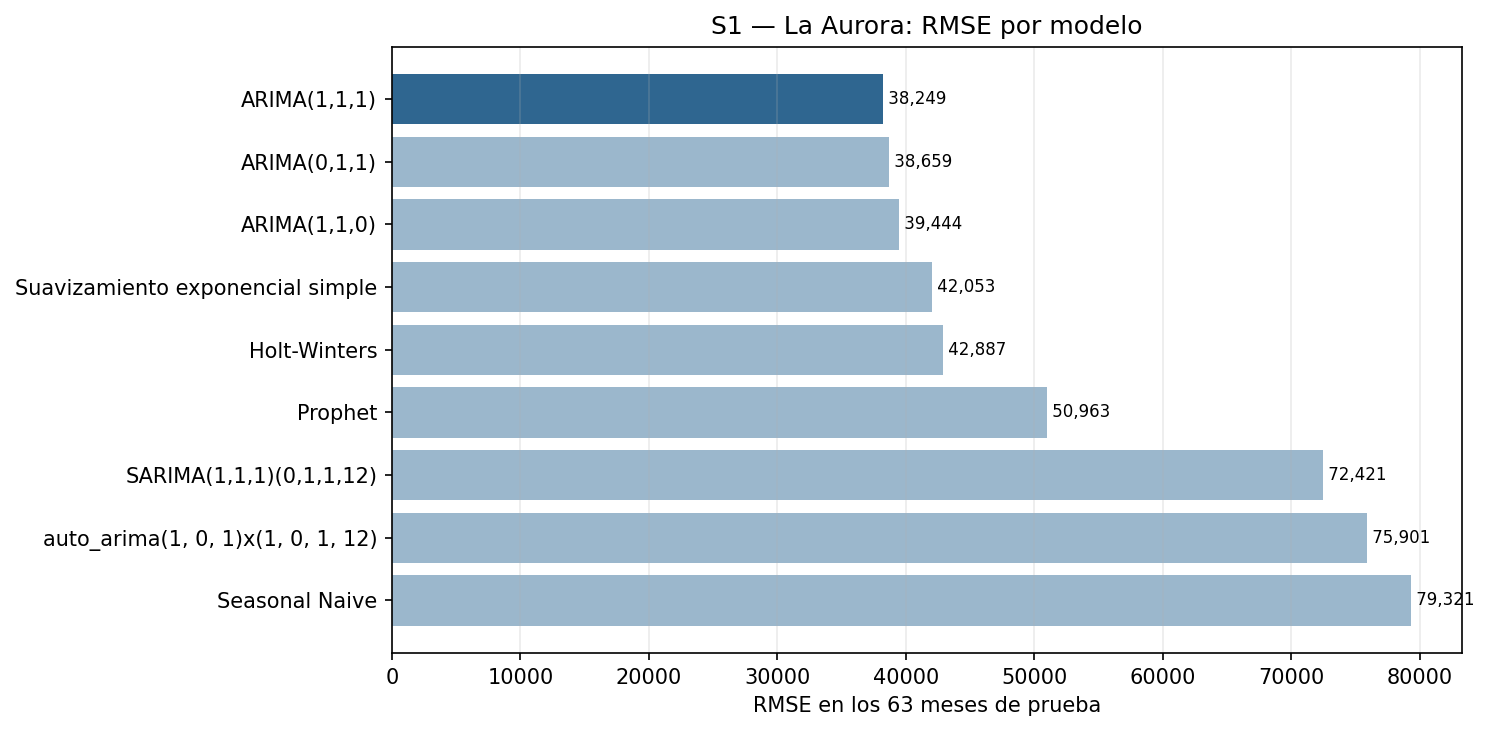

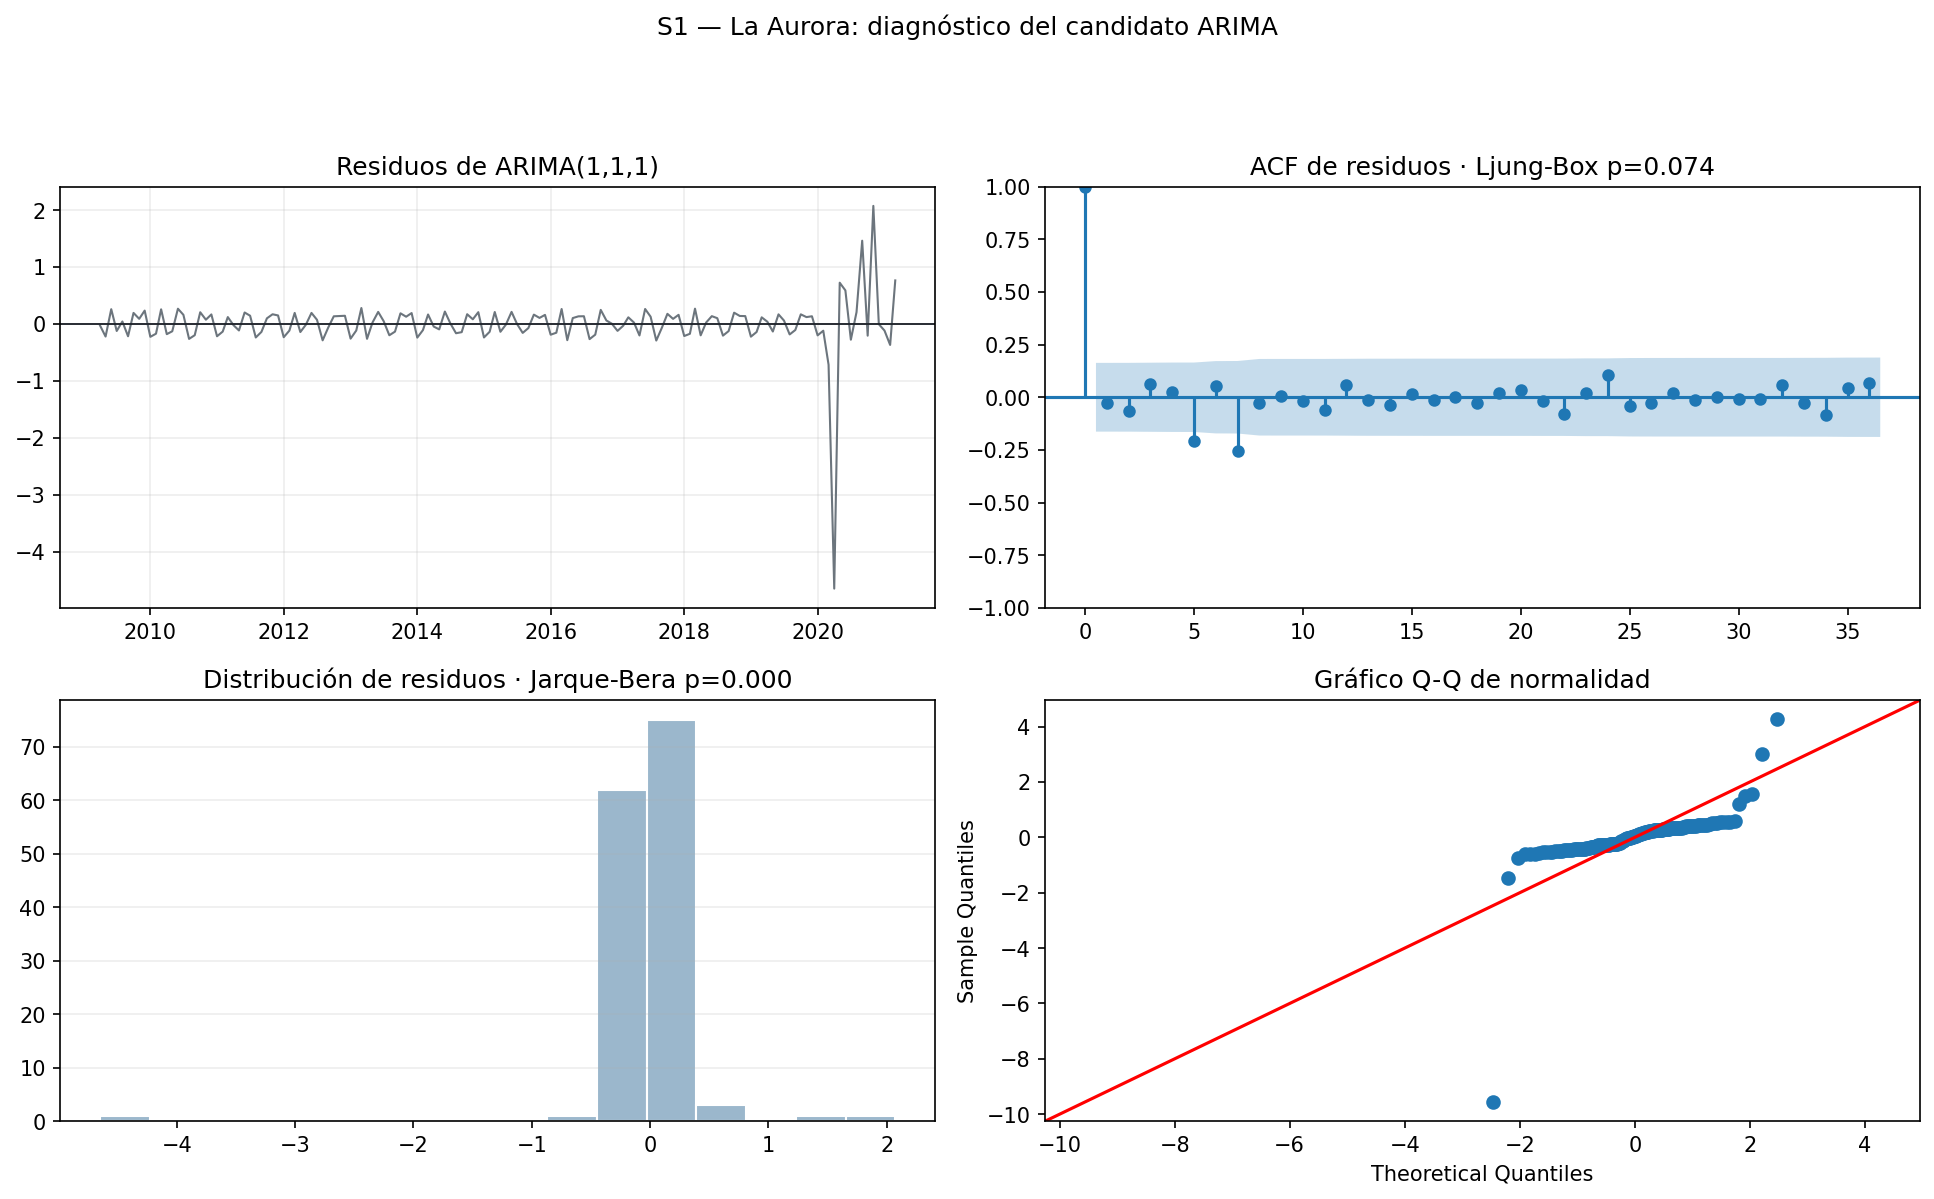

In [4]:
display(
    metricas.loc[
        metricas["serie"] == "S1_la_aurora",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s1_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s1_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s1_residuos.png")))

ARIMA(1,1,1) obtiene el menor RMSE de S1 (38,249). Ljung-Box no rechaza
autocorrelación al 5% (`p=0.074`), pero Jarque-Bera rechaza normalidad por las
colas generadas durante la pandemia.

## S2 — Valle Nuevo

Valle Nuevo tiene fuerza de tendencia 0.766 y fuerza estacional 0.311. La
relación media-desviación es más débil (0.310), por lo que se prefiere la
descomposición aditiva. El logaritmo elimina la asociación positiva entre
nivel y amplitud, aunque el choque de 2020 permanece visible.

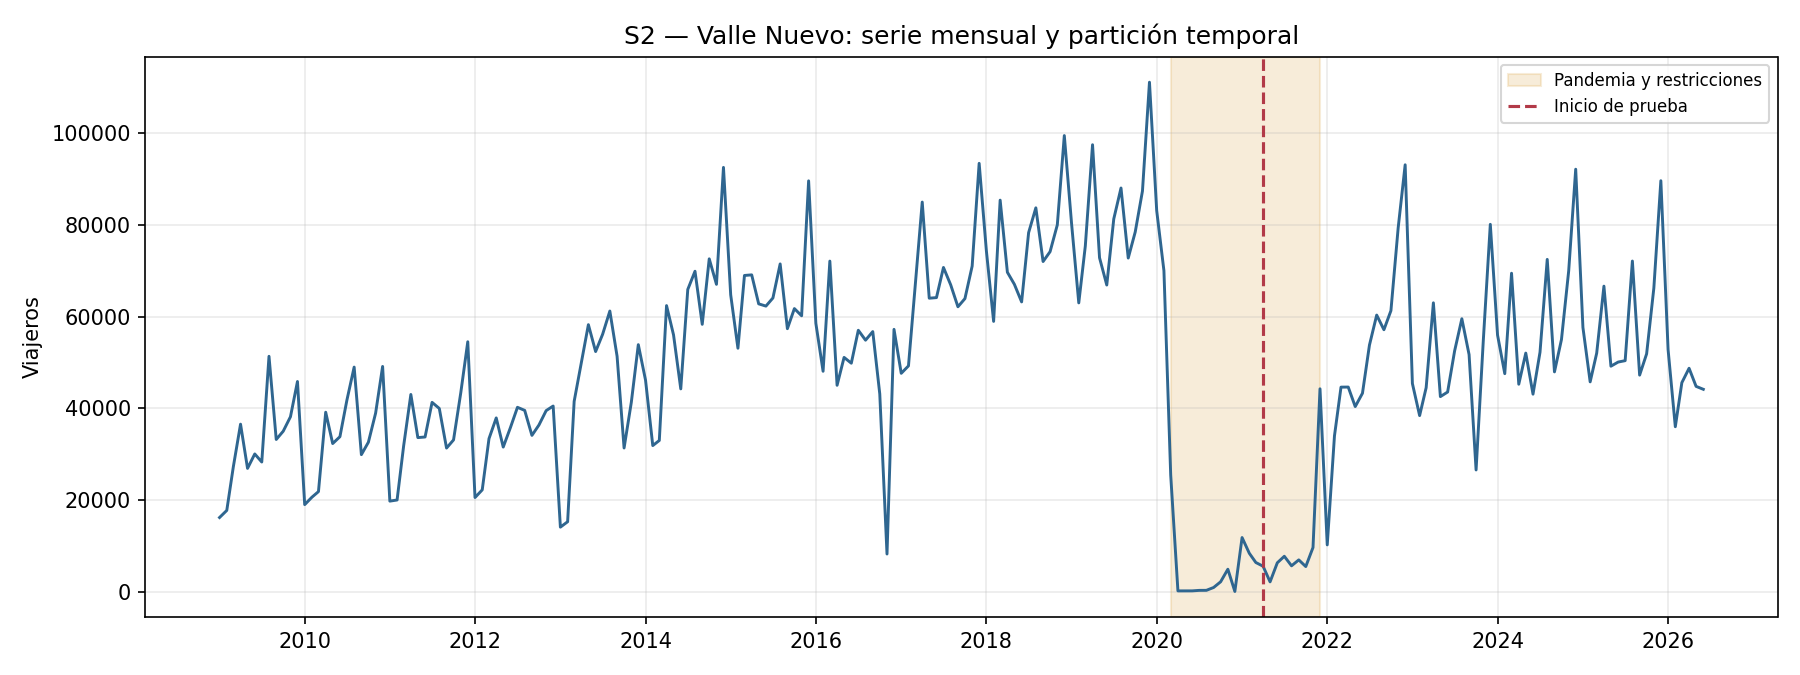

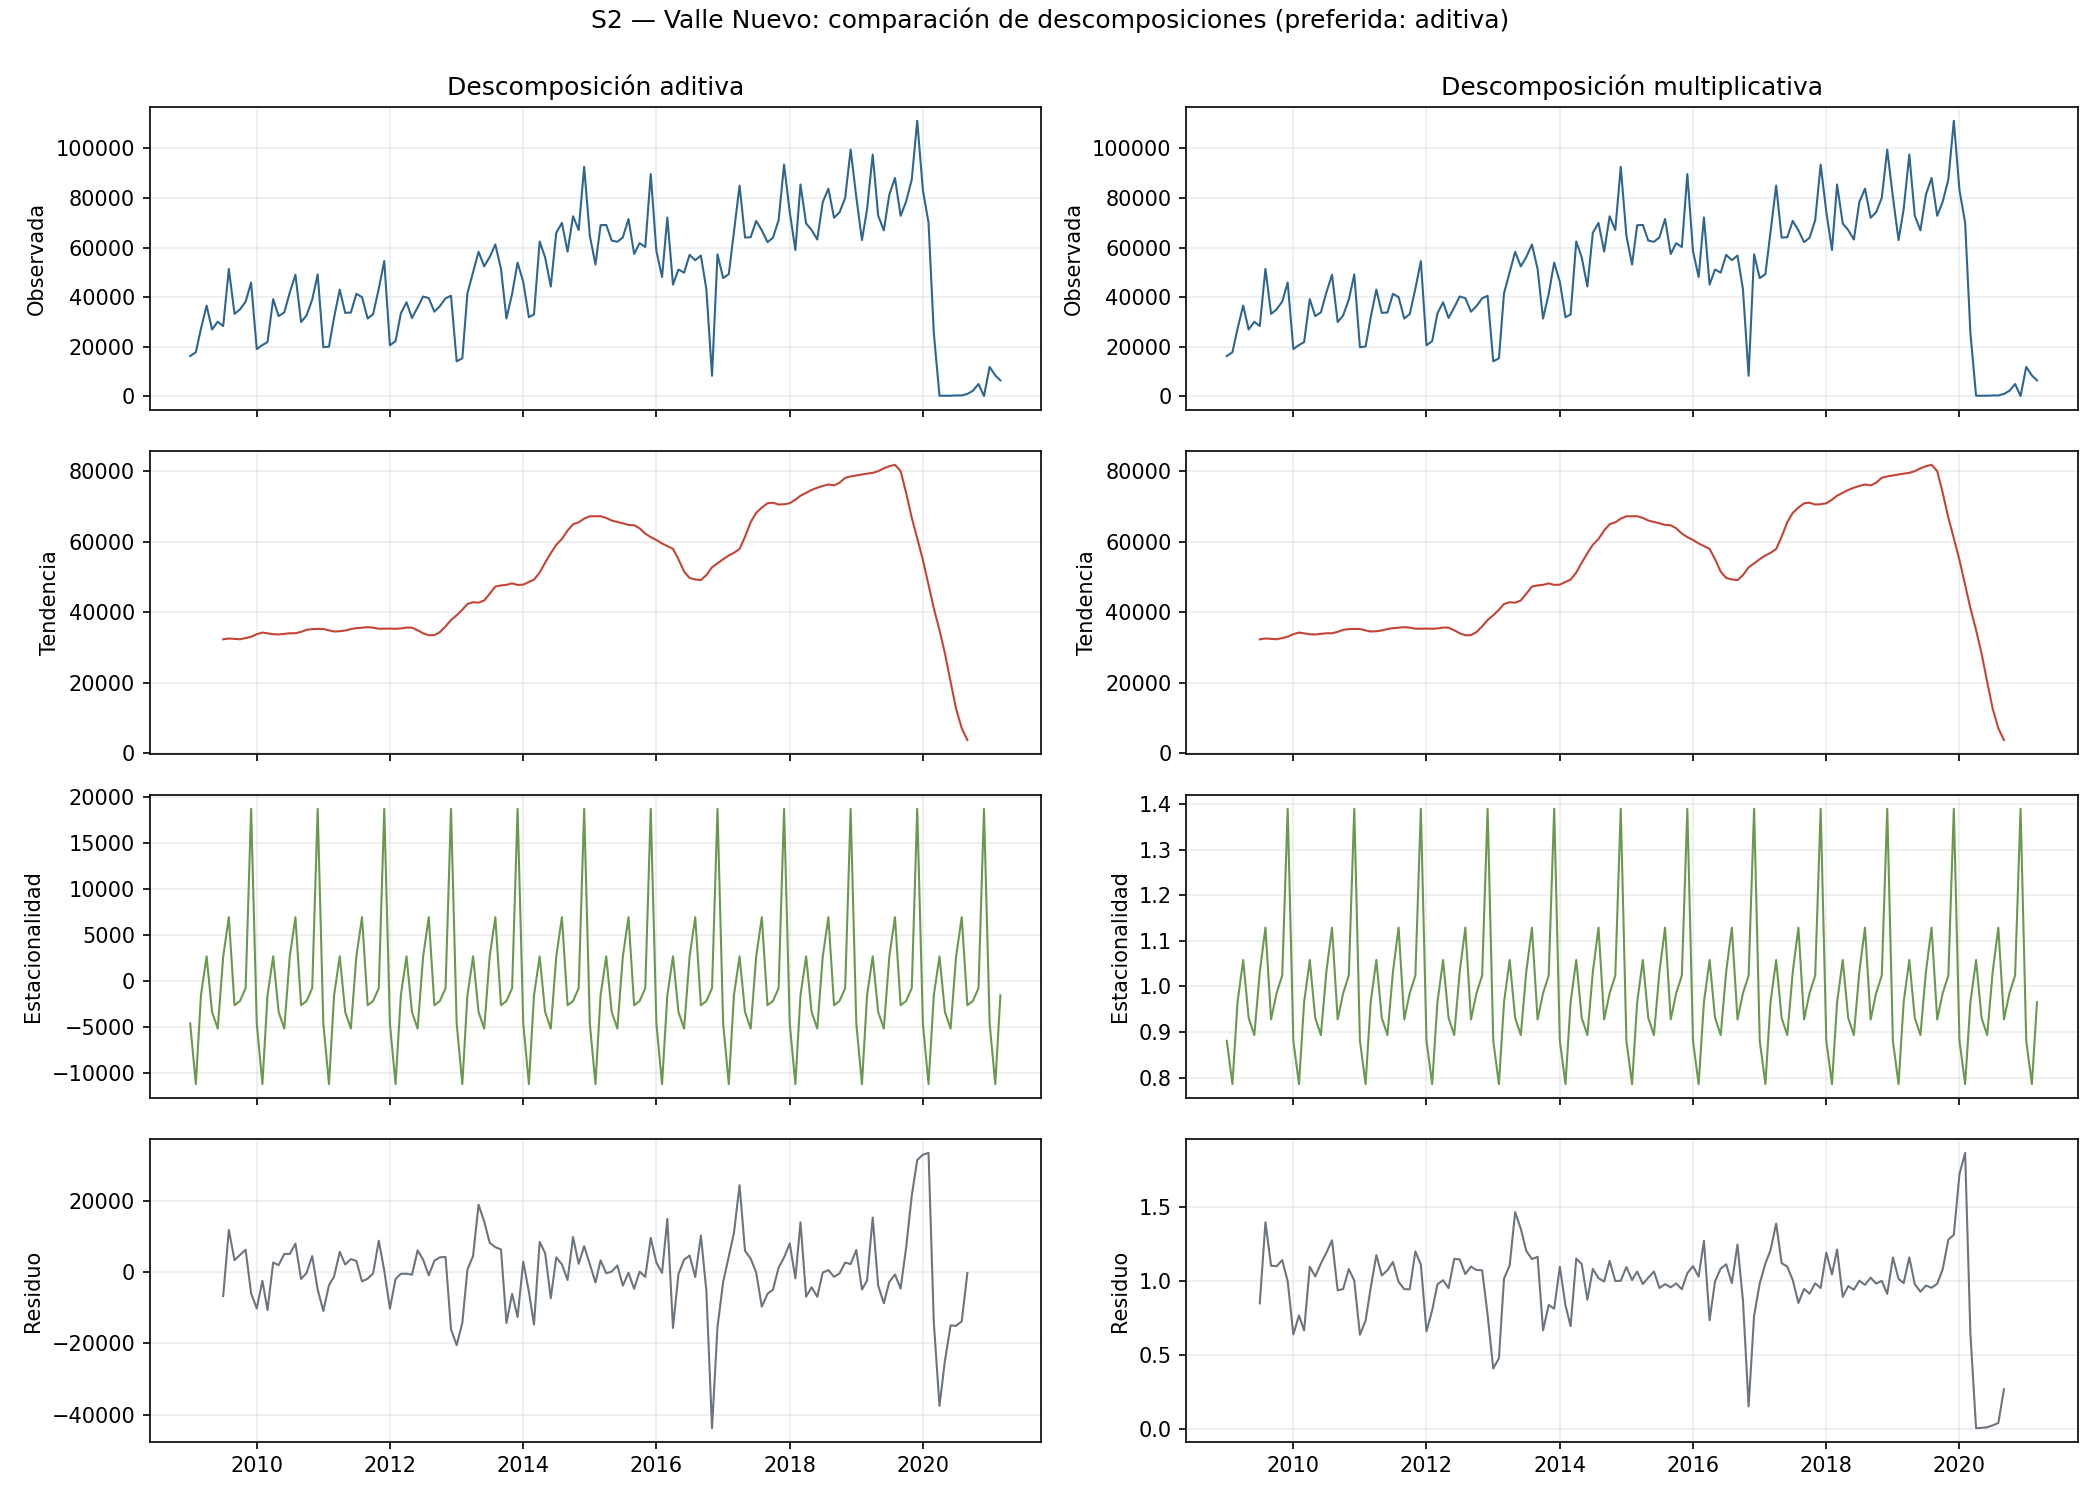

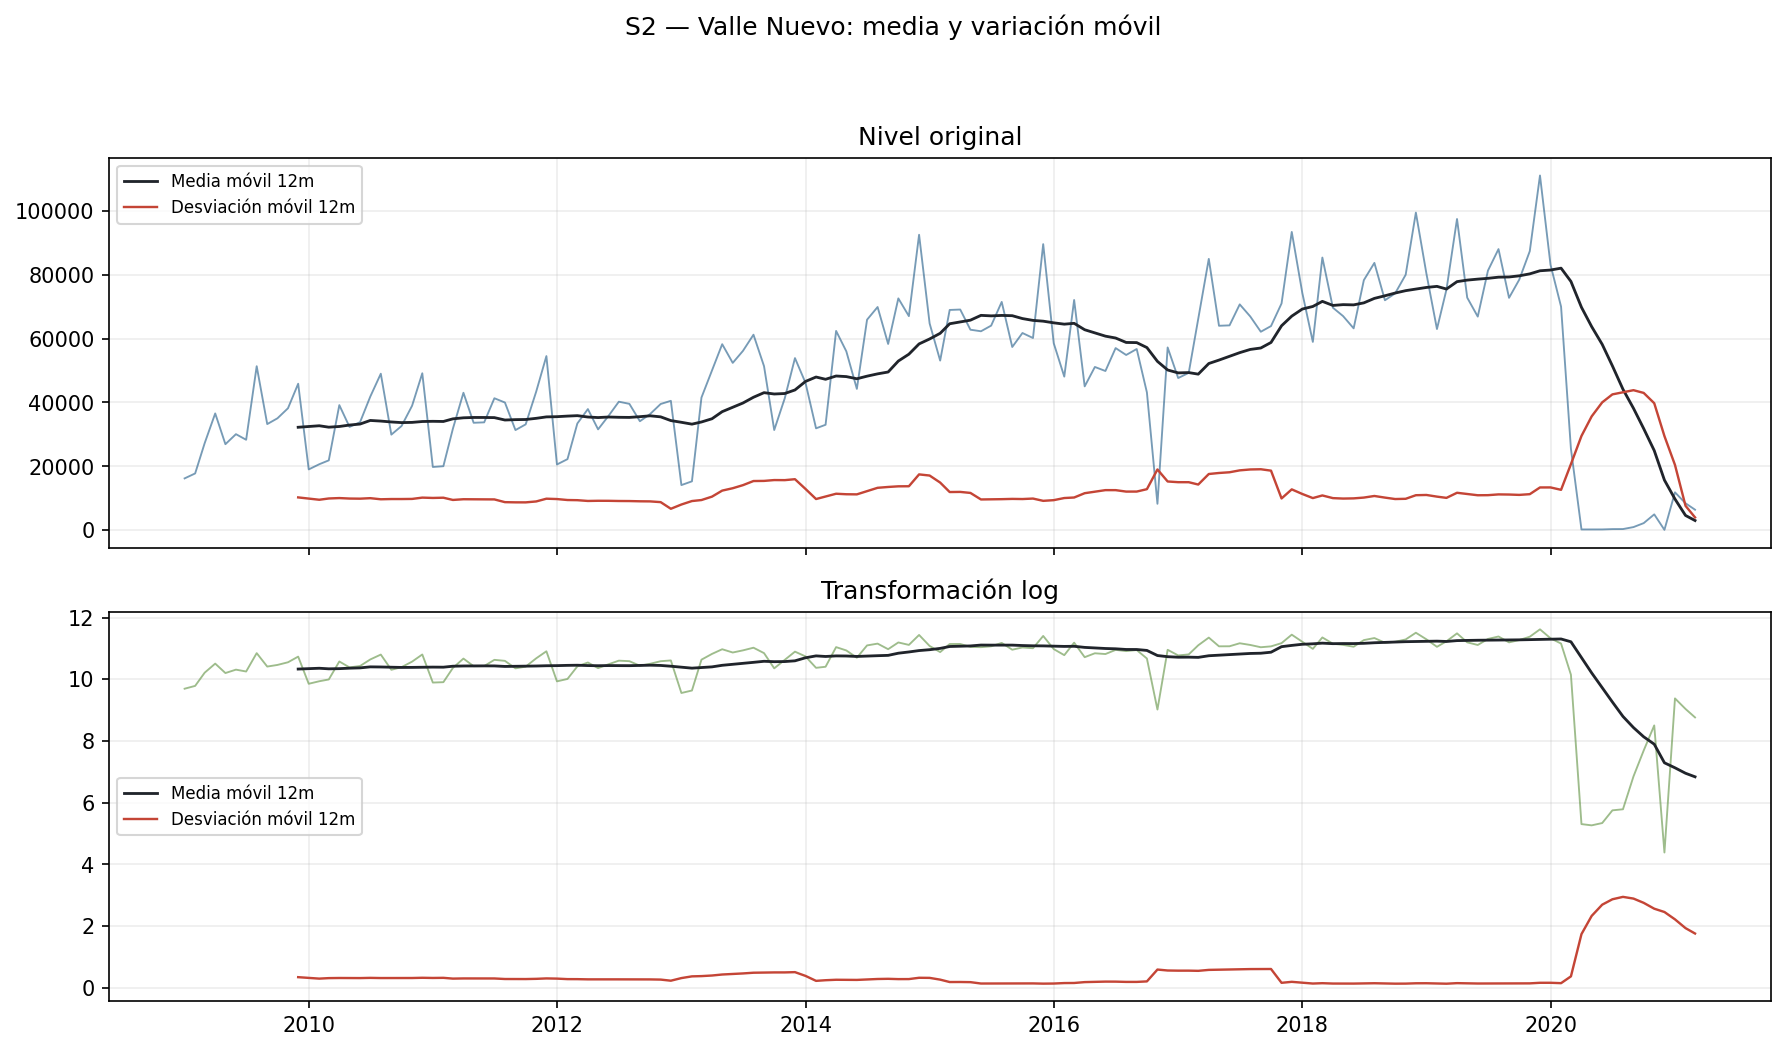

In [5]:
display(Image(filename=str(DIR_IMG / "s2_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s2_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s2_varianza.png")))

Con `d=1`, ADF y KPSS indican estacionariedad. ACF y PACF muestran una señal
negativa significativa en lag 1, lo que motiva contrastar AR(1), MA(1) y su
combinación antes de agregar la parte estacional.

,transformacion,p_ADF,p_KPSS,veredicto
5,Nivel,0.3648,0.0636,"resultado mixto: KPSS dice estacionaria, ADF no"
6,log,0.1952,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
7,log + d=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)
8,log + D=1,0.7827,0.0256,NO estacionaria (ambas pruebas coinciden)
9,log + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


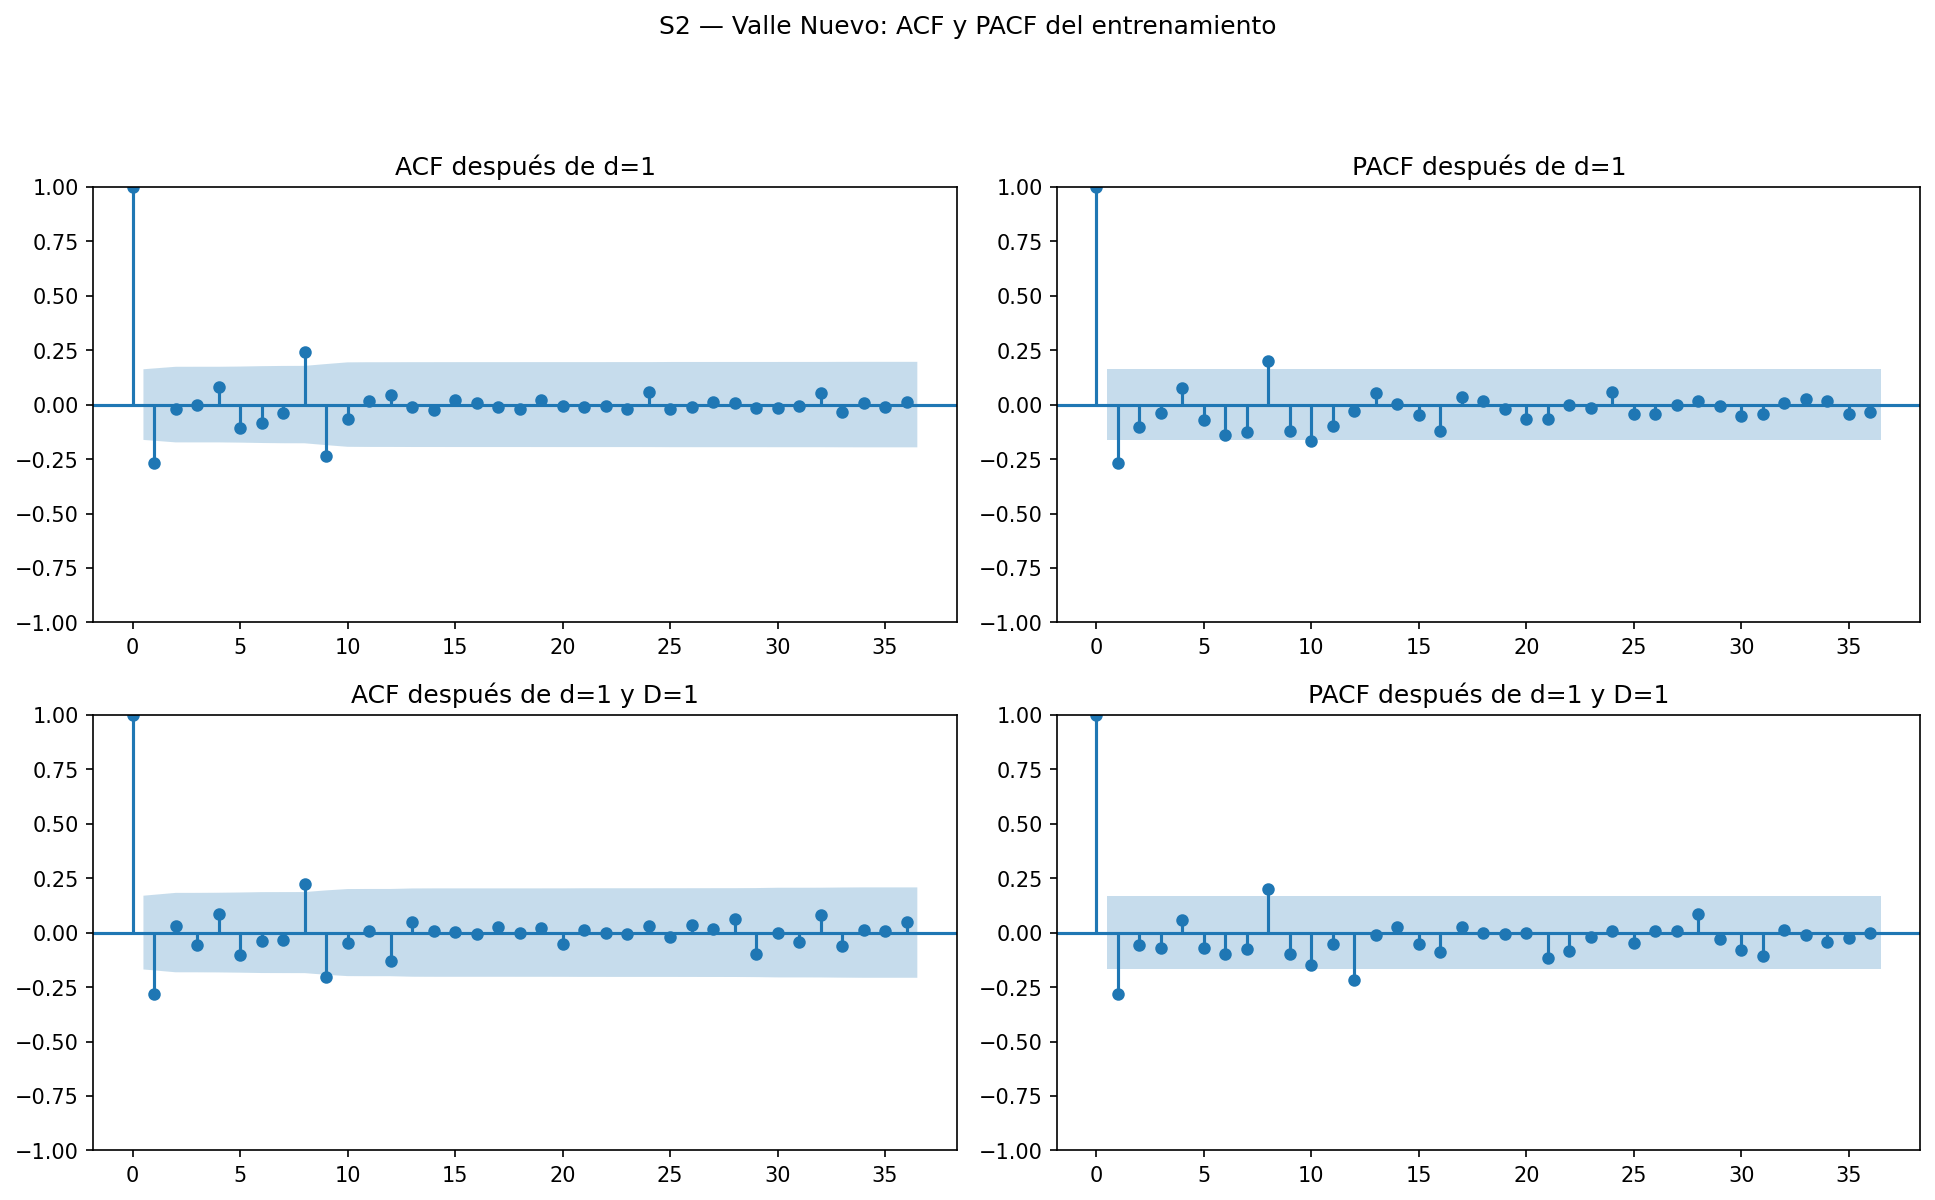

In [6]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S2_valle_nuevo",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s2_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
9,Prophet,NaN,NaN,16803.8514,23186.8219,157.6446,0.0000,0.0000,True
10,Holt-Winters,NaN,NaN,35209.7810,38091.0101,85.4327,0.8812,0.0000,False
11,Suavizamiento exponencial simple,NaN,NaN,40769.9154,45662.7777,79.9663,0.0000,0.0003,False
12,"ARIMA(1,1,0)",330.7410,336.6944,41024.4822,45933.3805,80.1076,0.0139,0.0000,False
13,"ARIMA(0,1,1)",327.5545,333.4941,41313.6887,46240.1210,80.3011,0.0496,0.0000,False
14,"ARIMA(1,1,1)",329.4996,338.4091,41518.9727,46452.1752,80.5179,0.0552,0.0000,False
15,"auto_arima(1, 0, 1)x(0, 0, 0, 12)",330.9773,339.9075,43693.0846,48726.1729,84.8307,0.0494,0.0000,False
16,Seasonal Naive,NaN,NaN,44707.2303,49660.5881,91.3852,0.0000,0.0000,False
17,"SARIMA(1,1,1)(0,1,1,12)",303.0943,314.2443,47115.3220,51805.5770,96.9598,0.1894,0.0000,False


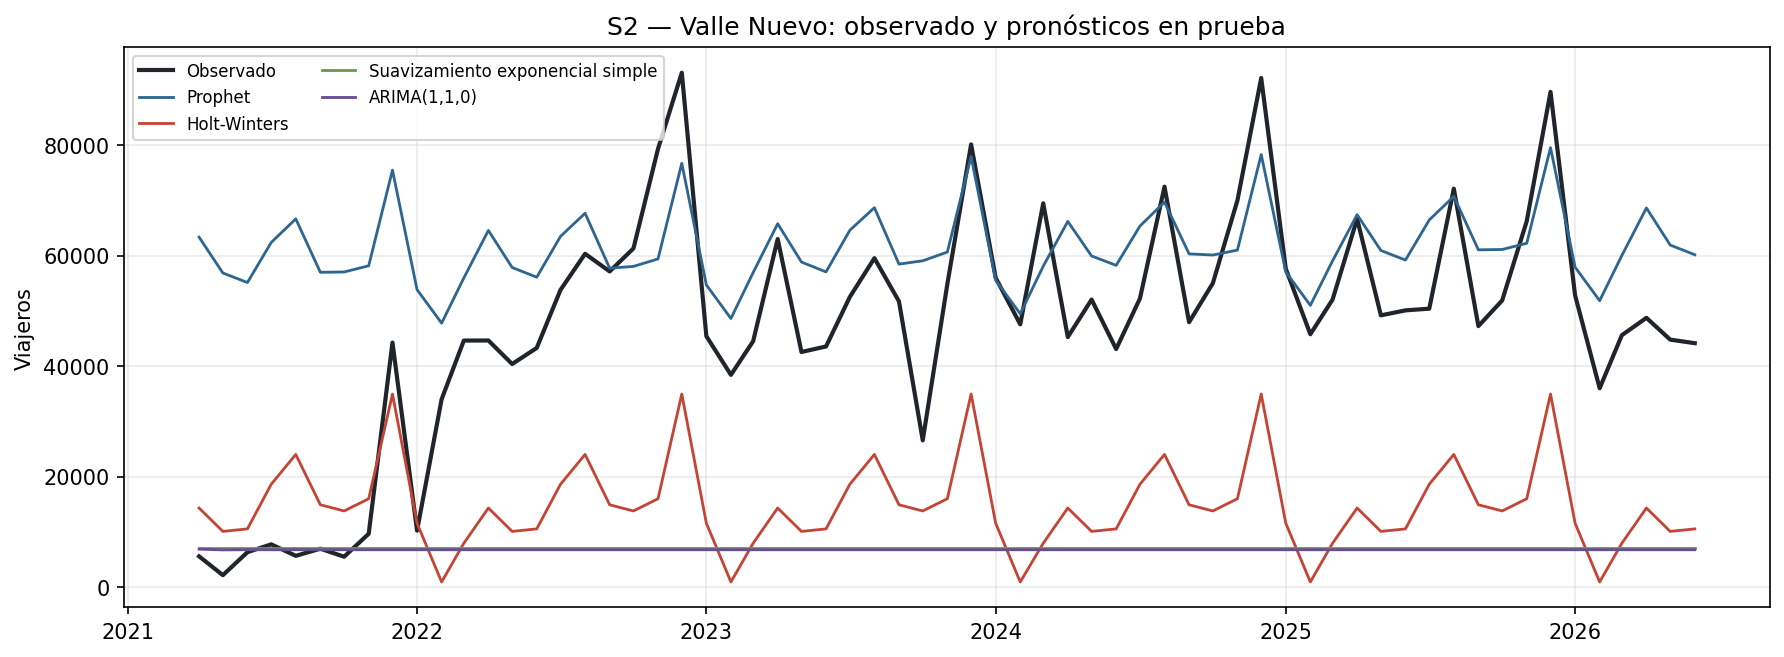

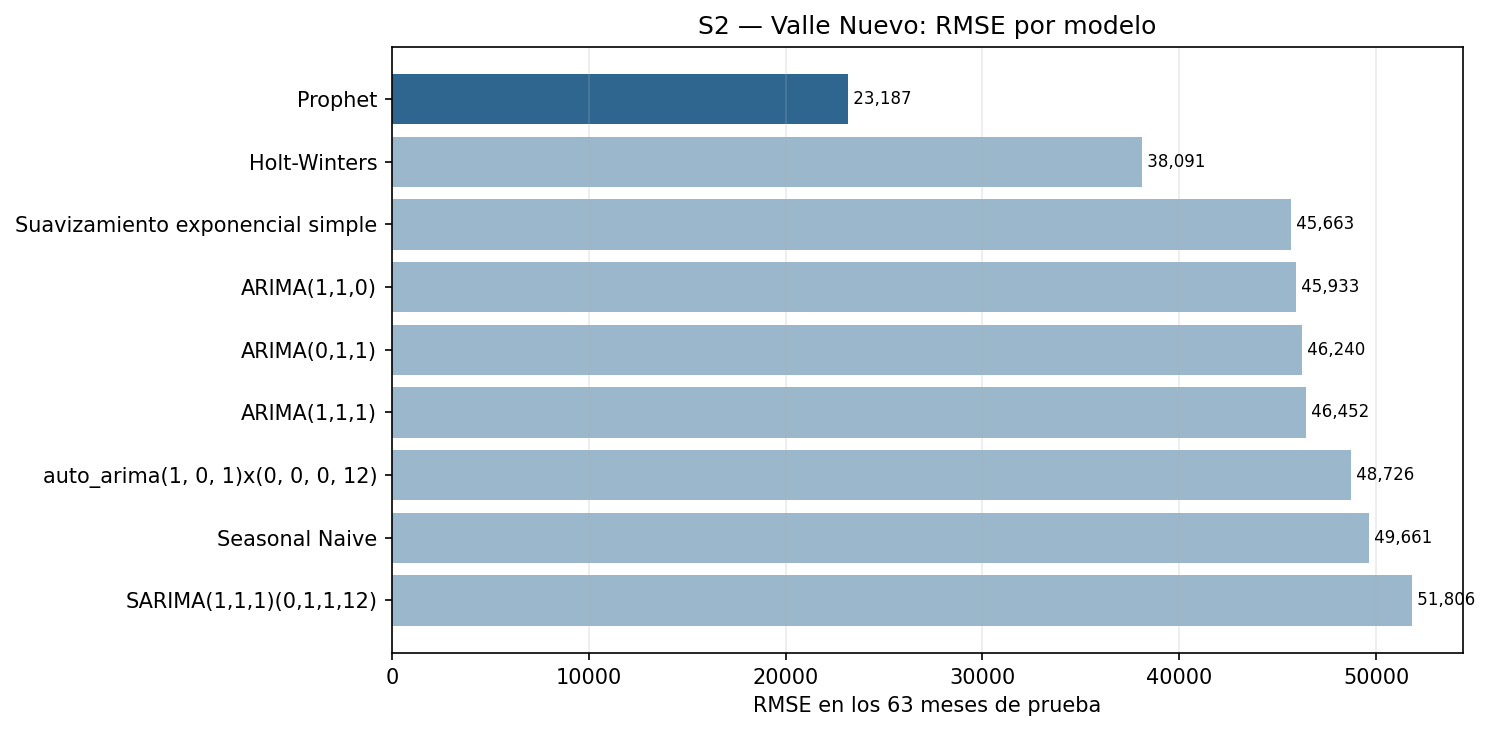

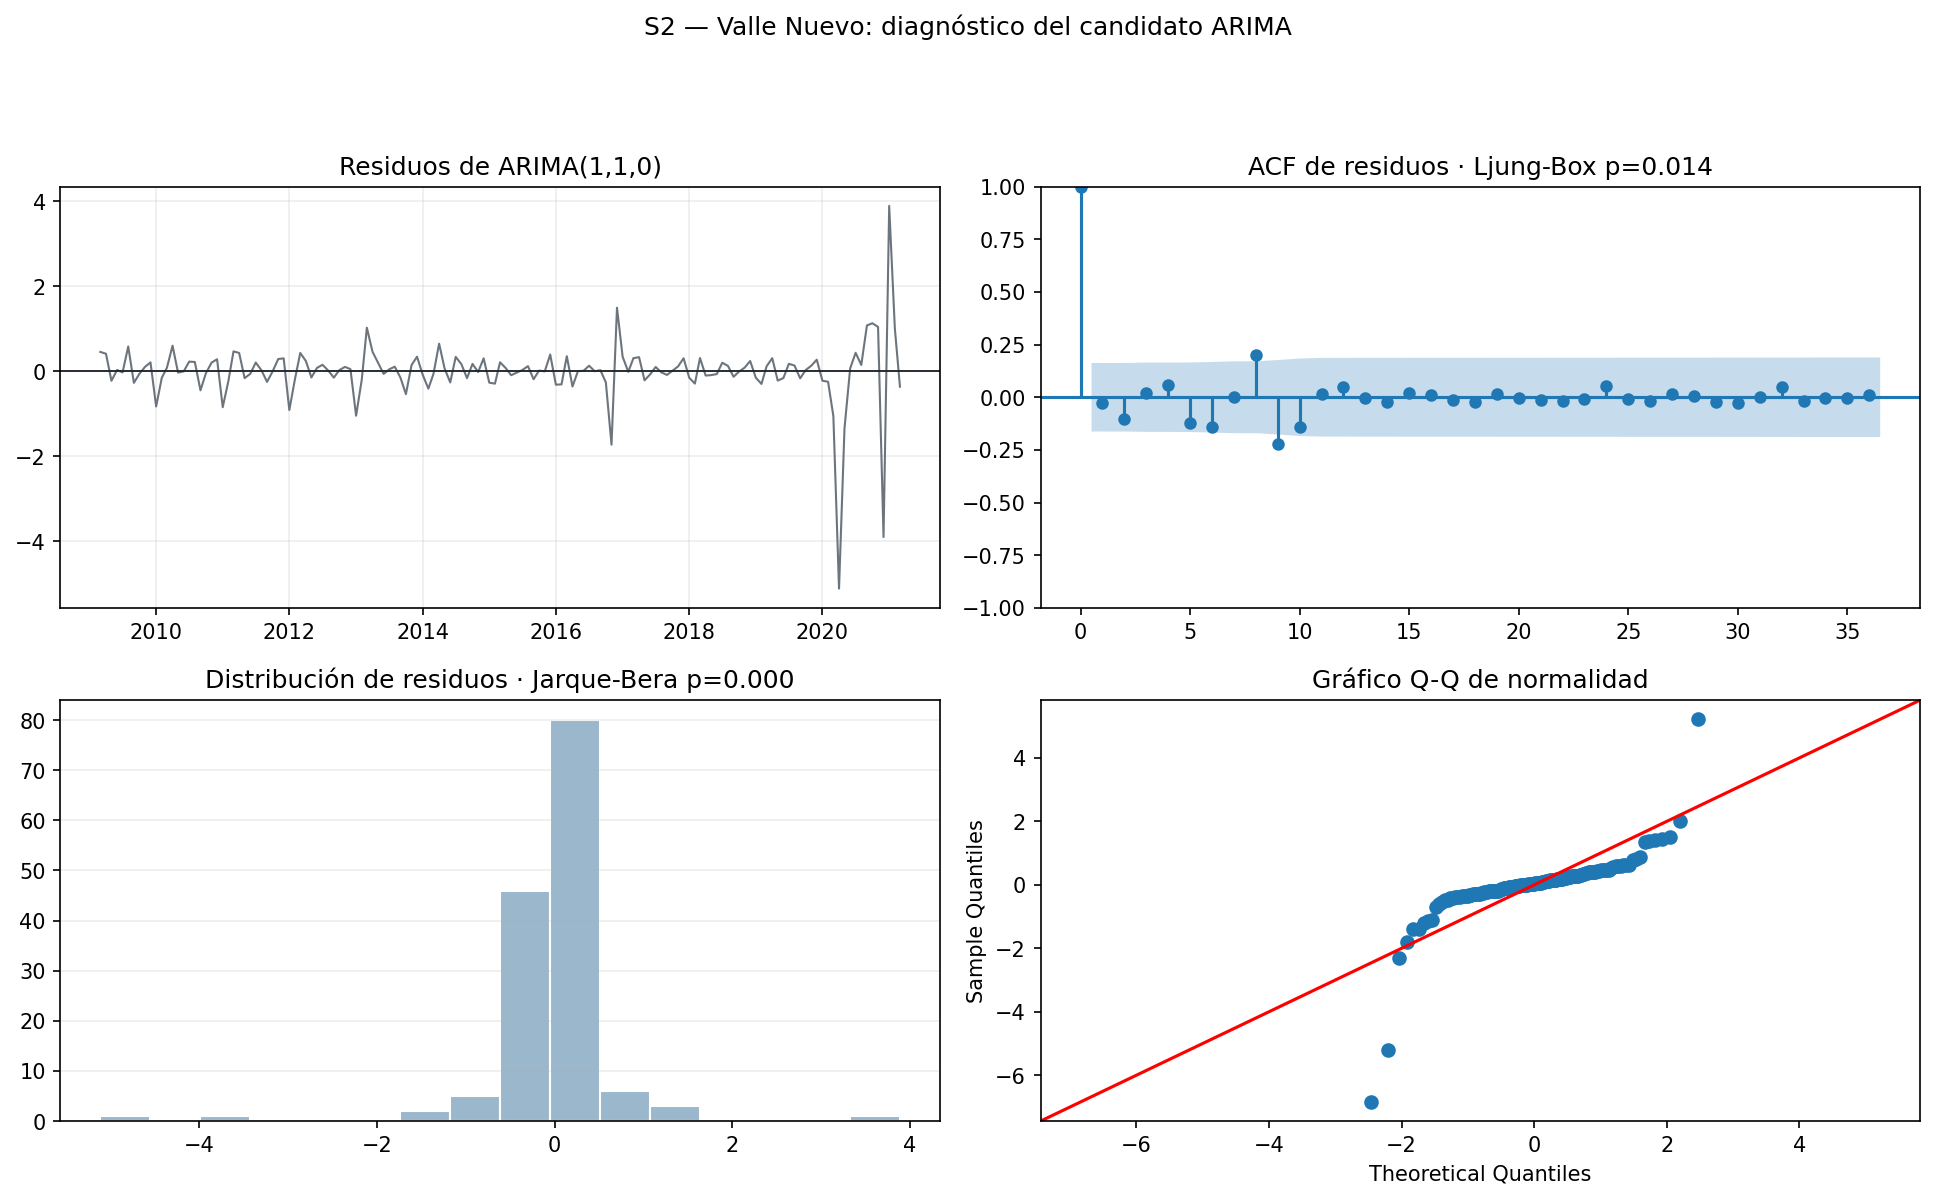

In [7]:
display(
    metricas.loc[
        metricas["serie"] == "S2_valle_nuevo",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s2_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s2_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s2_residuos.png")))

Prophet obtiene el menor RMSE de S2 (23,187), pero sus residuos conservan
autocorrelación. El MAPE supera 100% porque algunos meses observados son muy
pequeños; por eso la selección se basa en RMSE.

## S3 — San Cristóbal

San Cristóbal completa el Top 3. Tiene fuerza de tendencia 0.707 y fuerza
estacional 0.399. La correlación media-desviación prepandemia es 0.529, por lo
que se prefiere una lectura multiplicativa; después del logaritmo baja a
-0.468.

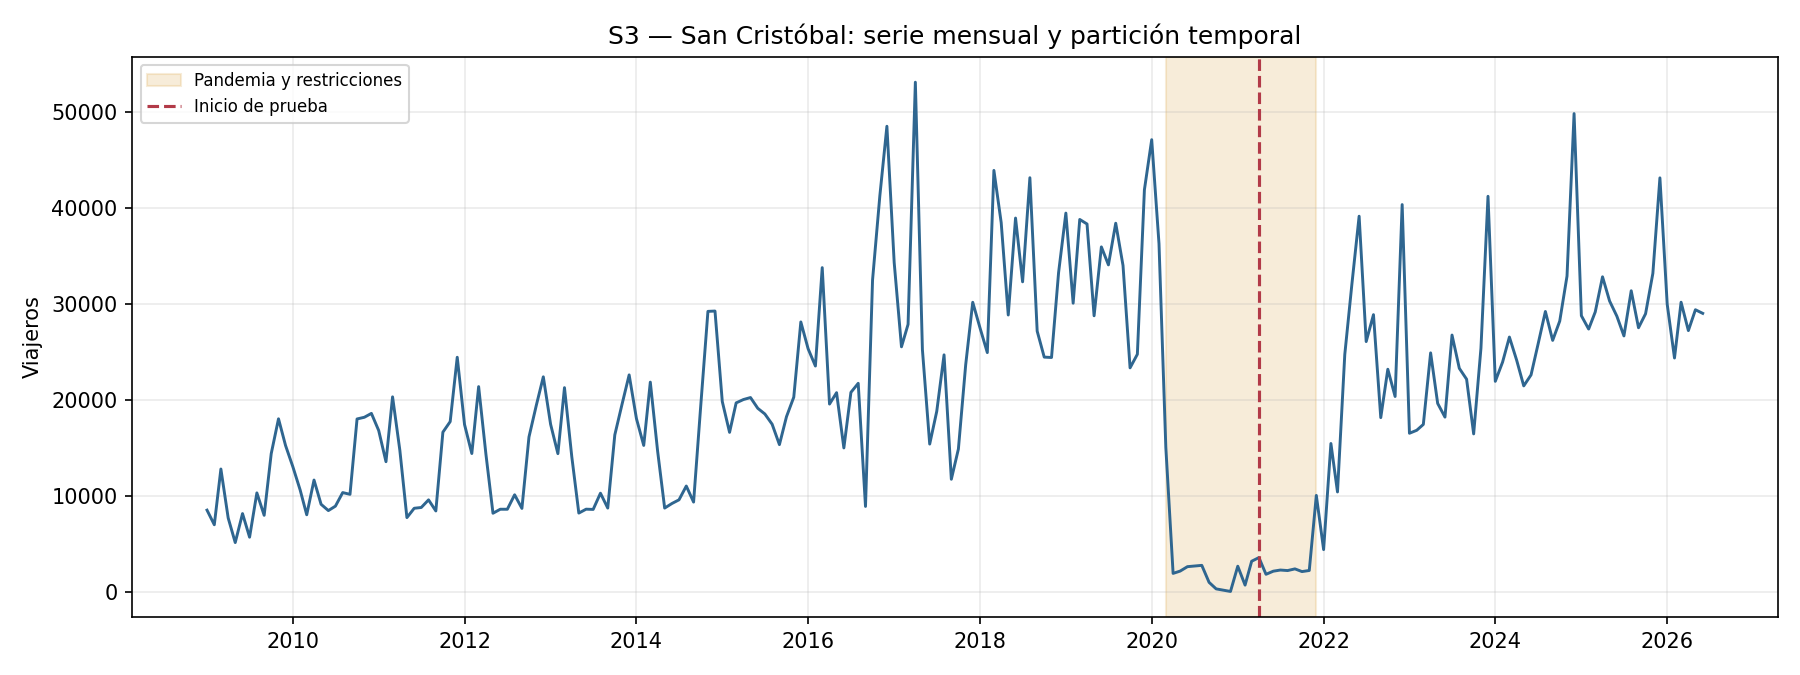

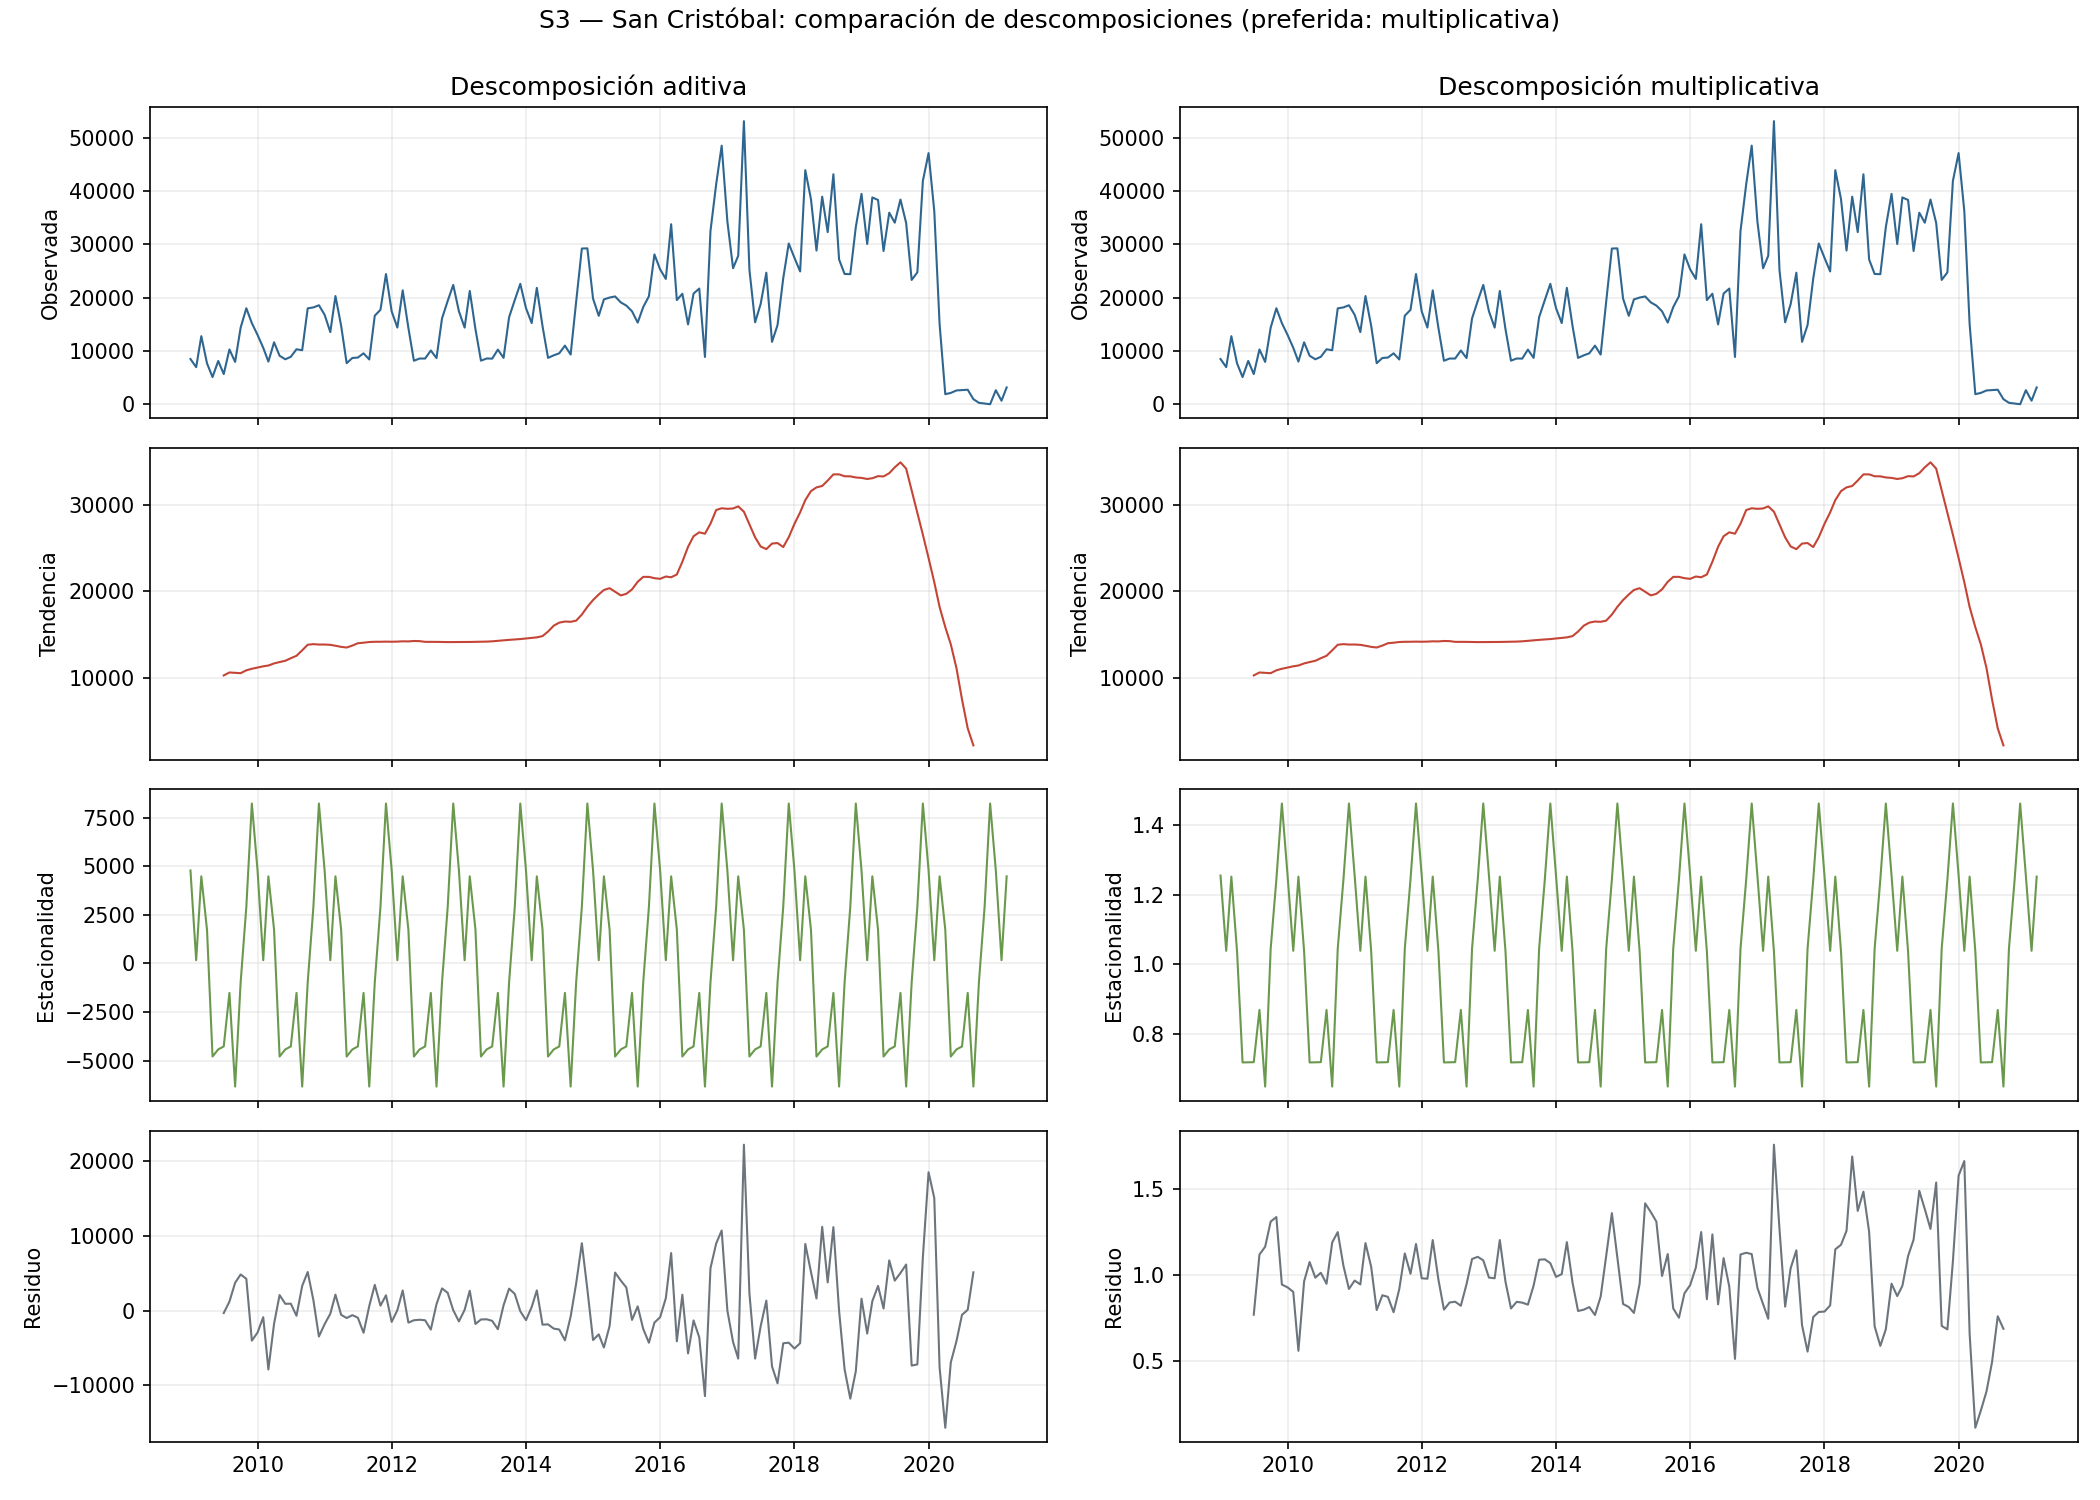

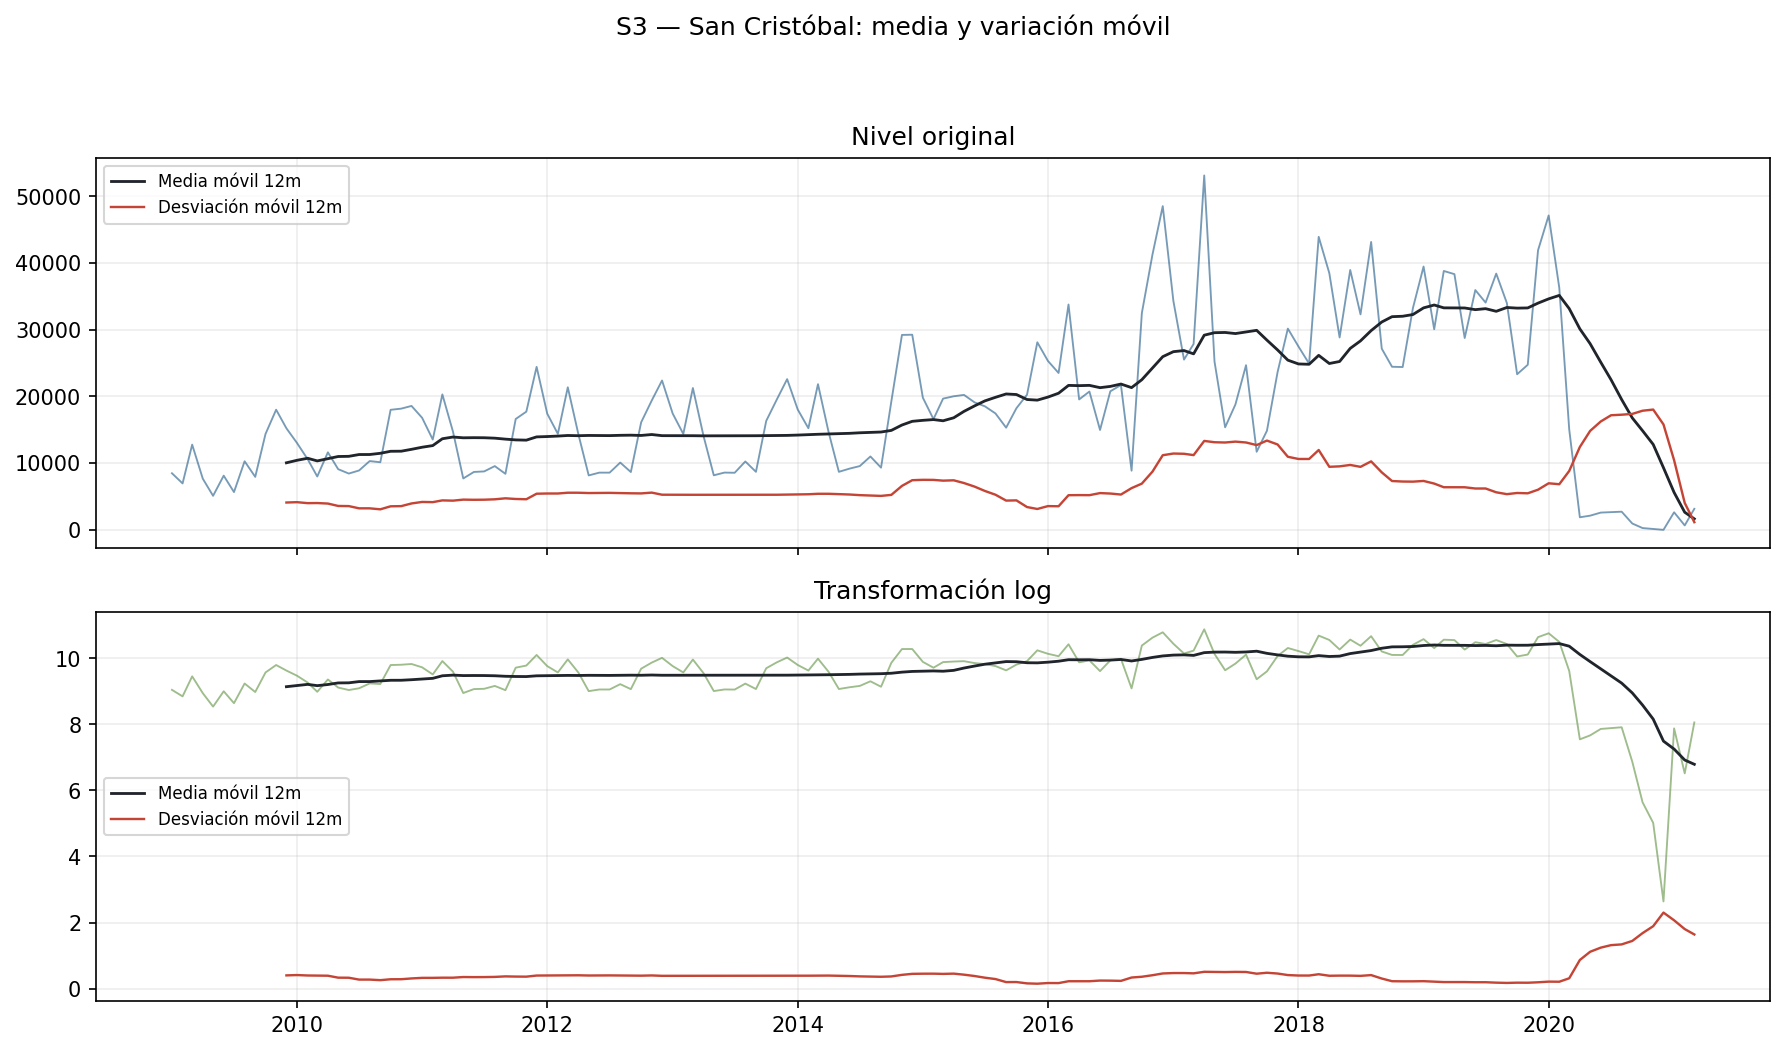

In [8]:
display(Image(filename=str(DIR_IMG / "s3_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s3_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s3_varianza.png")))

S3 requiere `d=1,D=1`: la primera diferencia regular no basta según ADF, pero
la combinación regular y estacional obtiene acuerdo con KPSS. La señal
principal de ACF/PACF tras `d=1` está en lag 1; se comparan AR(1), MA(1), su
combinación y un SARIMA anual.

,transformacion,p_ADF,p_KPSS,veredicto
10,Nivel,0.5854,0.0208,NO estacionaria (ambas pruebas coinciden)
11,log,0.2527,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
12,log + d=1,0.9121,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
13,log + D=1,0.9269,0.0242,NO estacionaria (ambas pruebas coinciden)
14,log + d=1 + D=1,0.0002,0.1000,estacionaria (ambas pruebas coinciden)


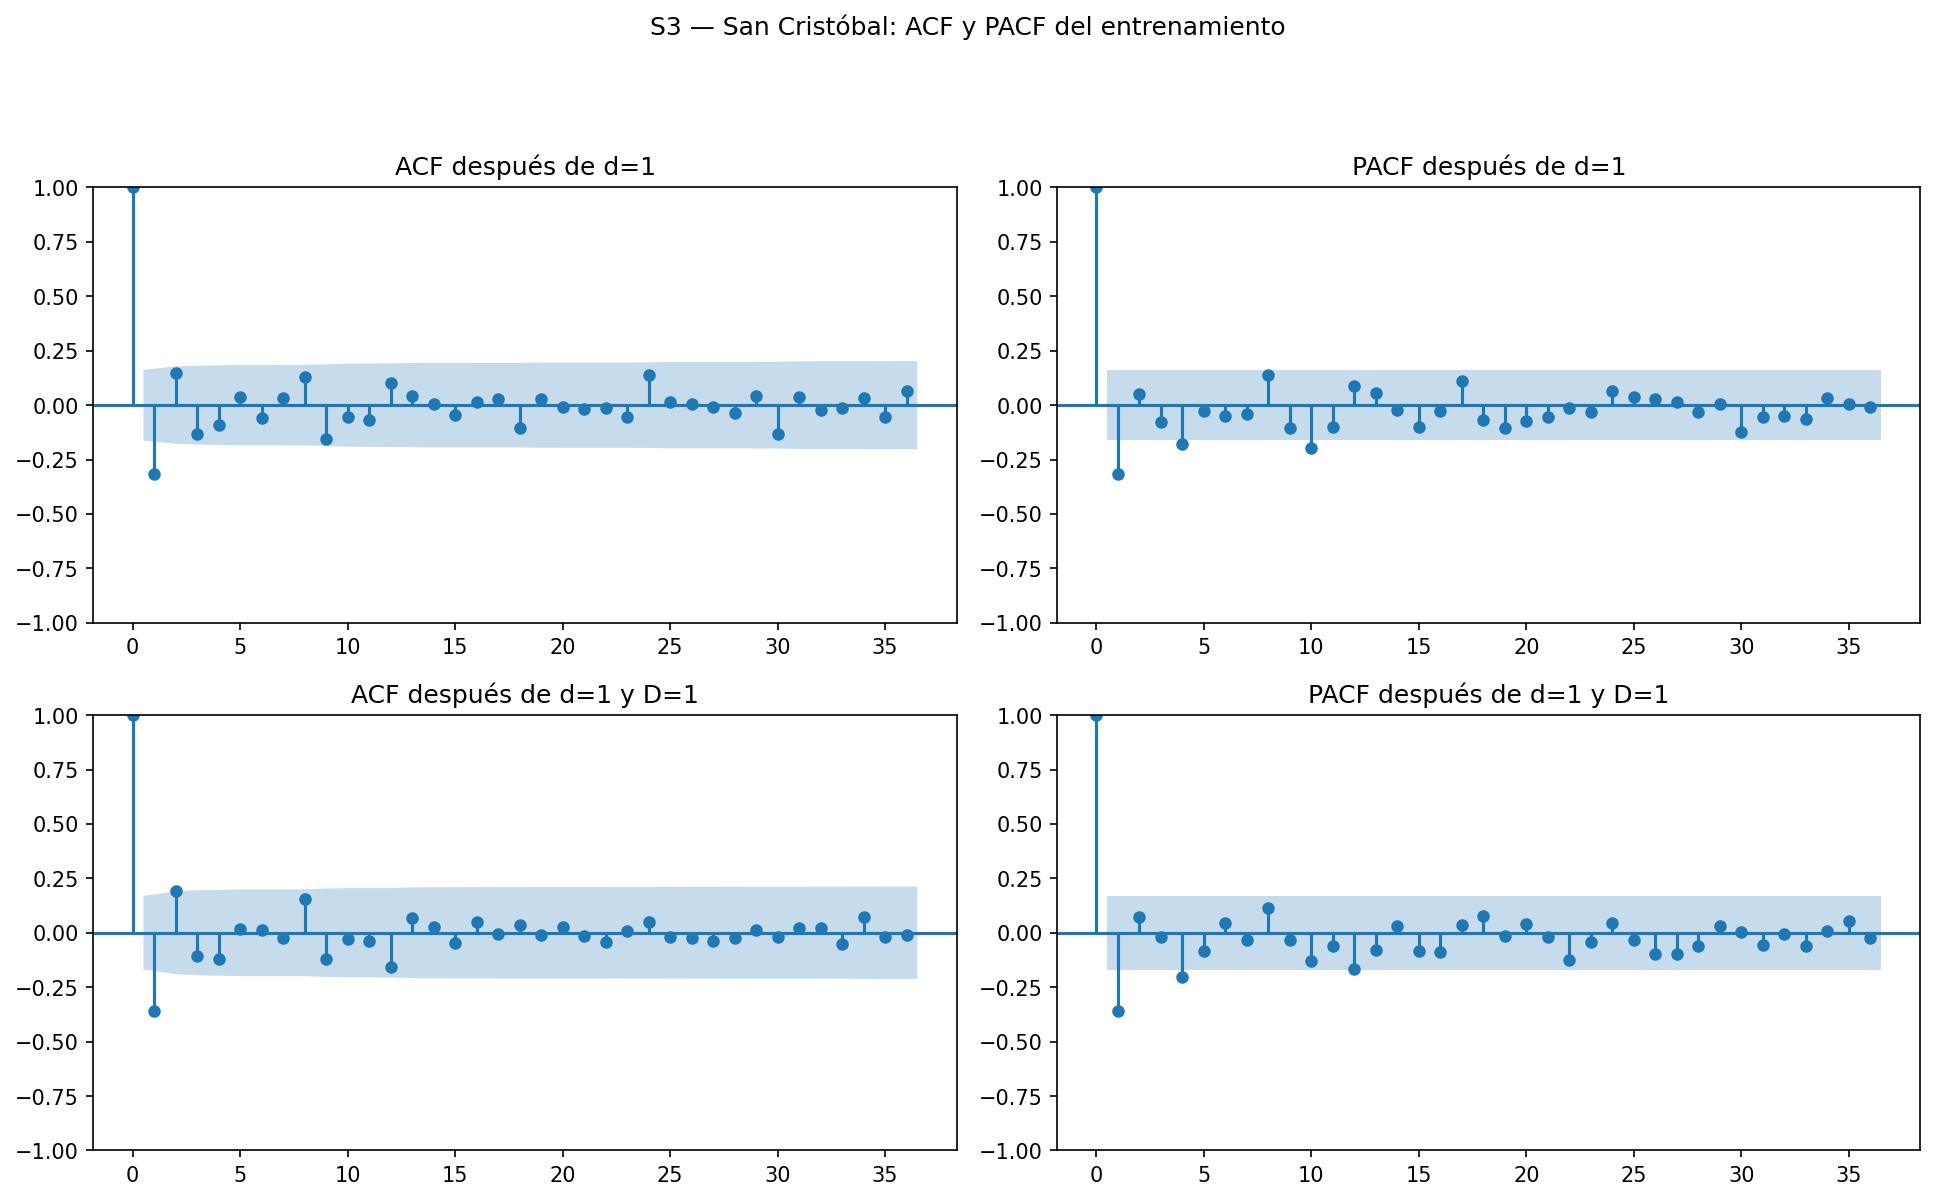

In [9]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S3_san_cristobal",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s3_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
18,Prophet,NaN,NaN,7723.2948,10437.1069,146.8912,0.0000,0.0,True
19,Suavizamiento exponencial simple,NaN,NaN,20483.0739,23091.4784,80.0269,0.0000,0.0,False
20,"ARIMA(1,1,0)",274.7171,280.6706,20896.6430,23543.5057,80.2579,0.0332,0.0,False
21,"ARIMA(1,1,1)",273.9593,282.8687,21067.4089,23694.3538,81.8654,0.0399,0.0,False
22,"ARIMA(0,1,1)",274.7365,280.6761,21094.2888,23732.0655,81.5899,0.0460,0.0,False
23,Seasonal Naive,NaN,NaN,21407.9507,24052.5238,86.2266,0.0000,0.0,False
24,Holt-Winters,NaN,NaN,22180.1537,24610.9879,94.0779,0.0072,0.0,False
25,"auto_arima(2, 0, 1)x(1, 0, 0, 12)",254.1636,268.6154,22869.8601,25382.6475,96.4963,0.1235,0.0,False
26,"SARIMA(1,1,1)(0,1,1,12)",239.0442,250.1942,22941.2158,25446.6547,97.1934,0.1277,0.0,False


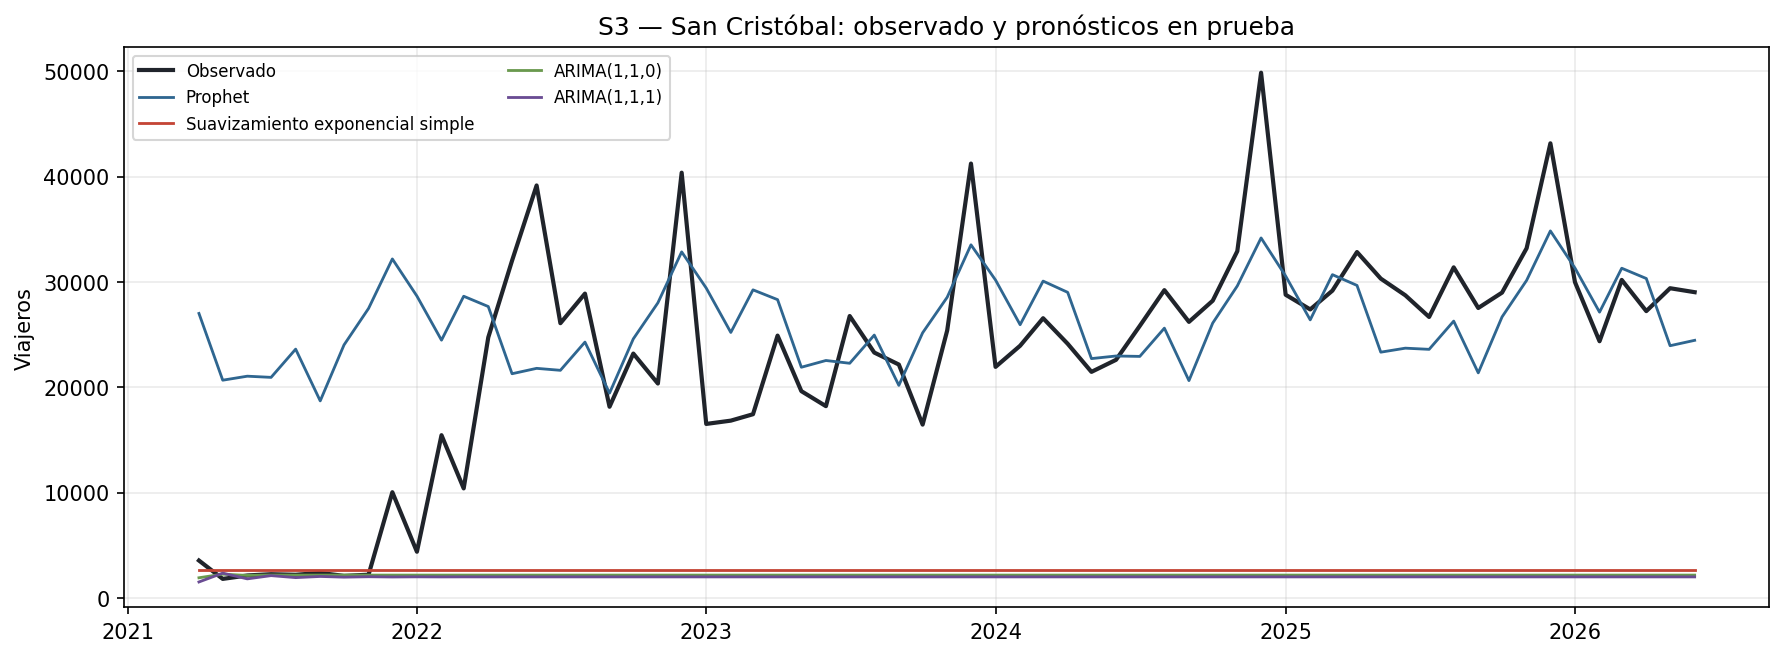

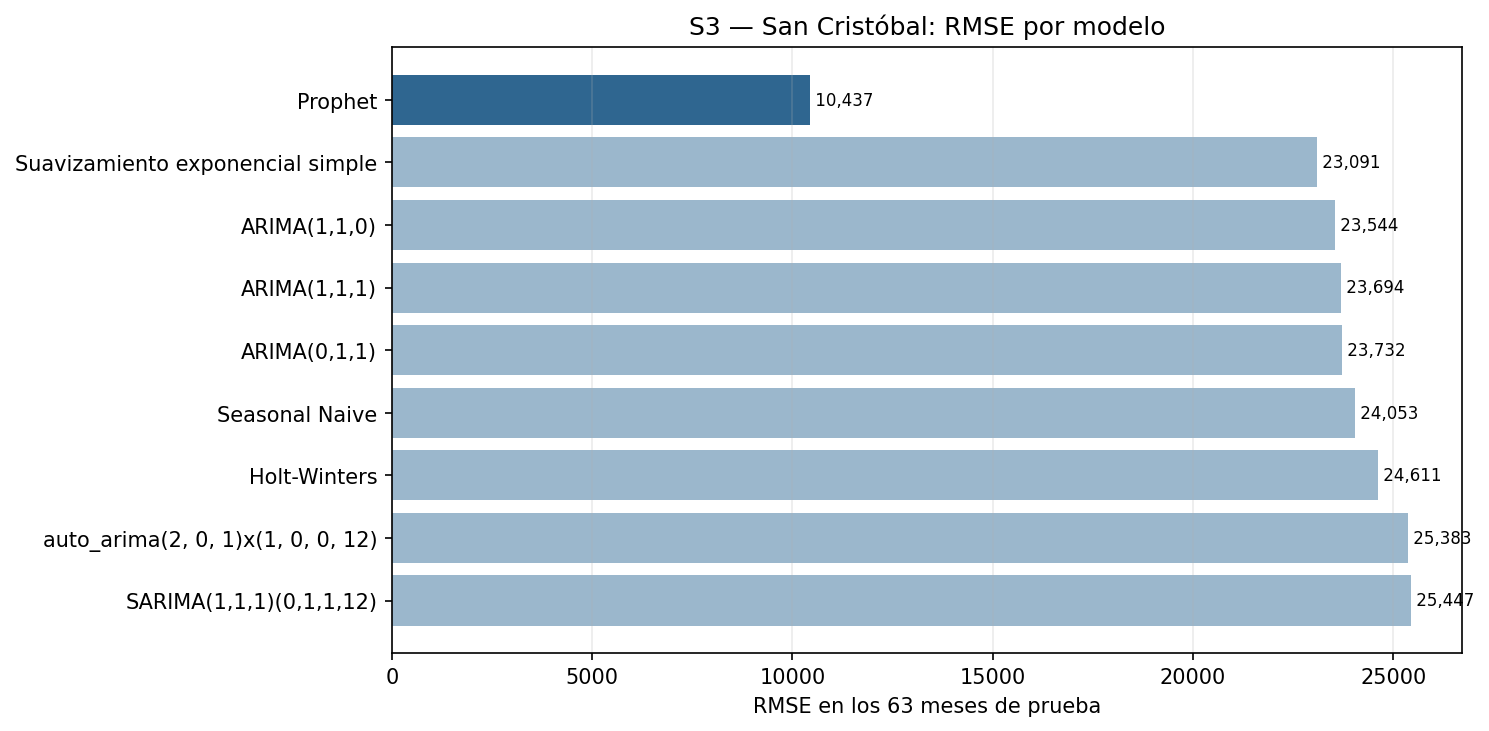

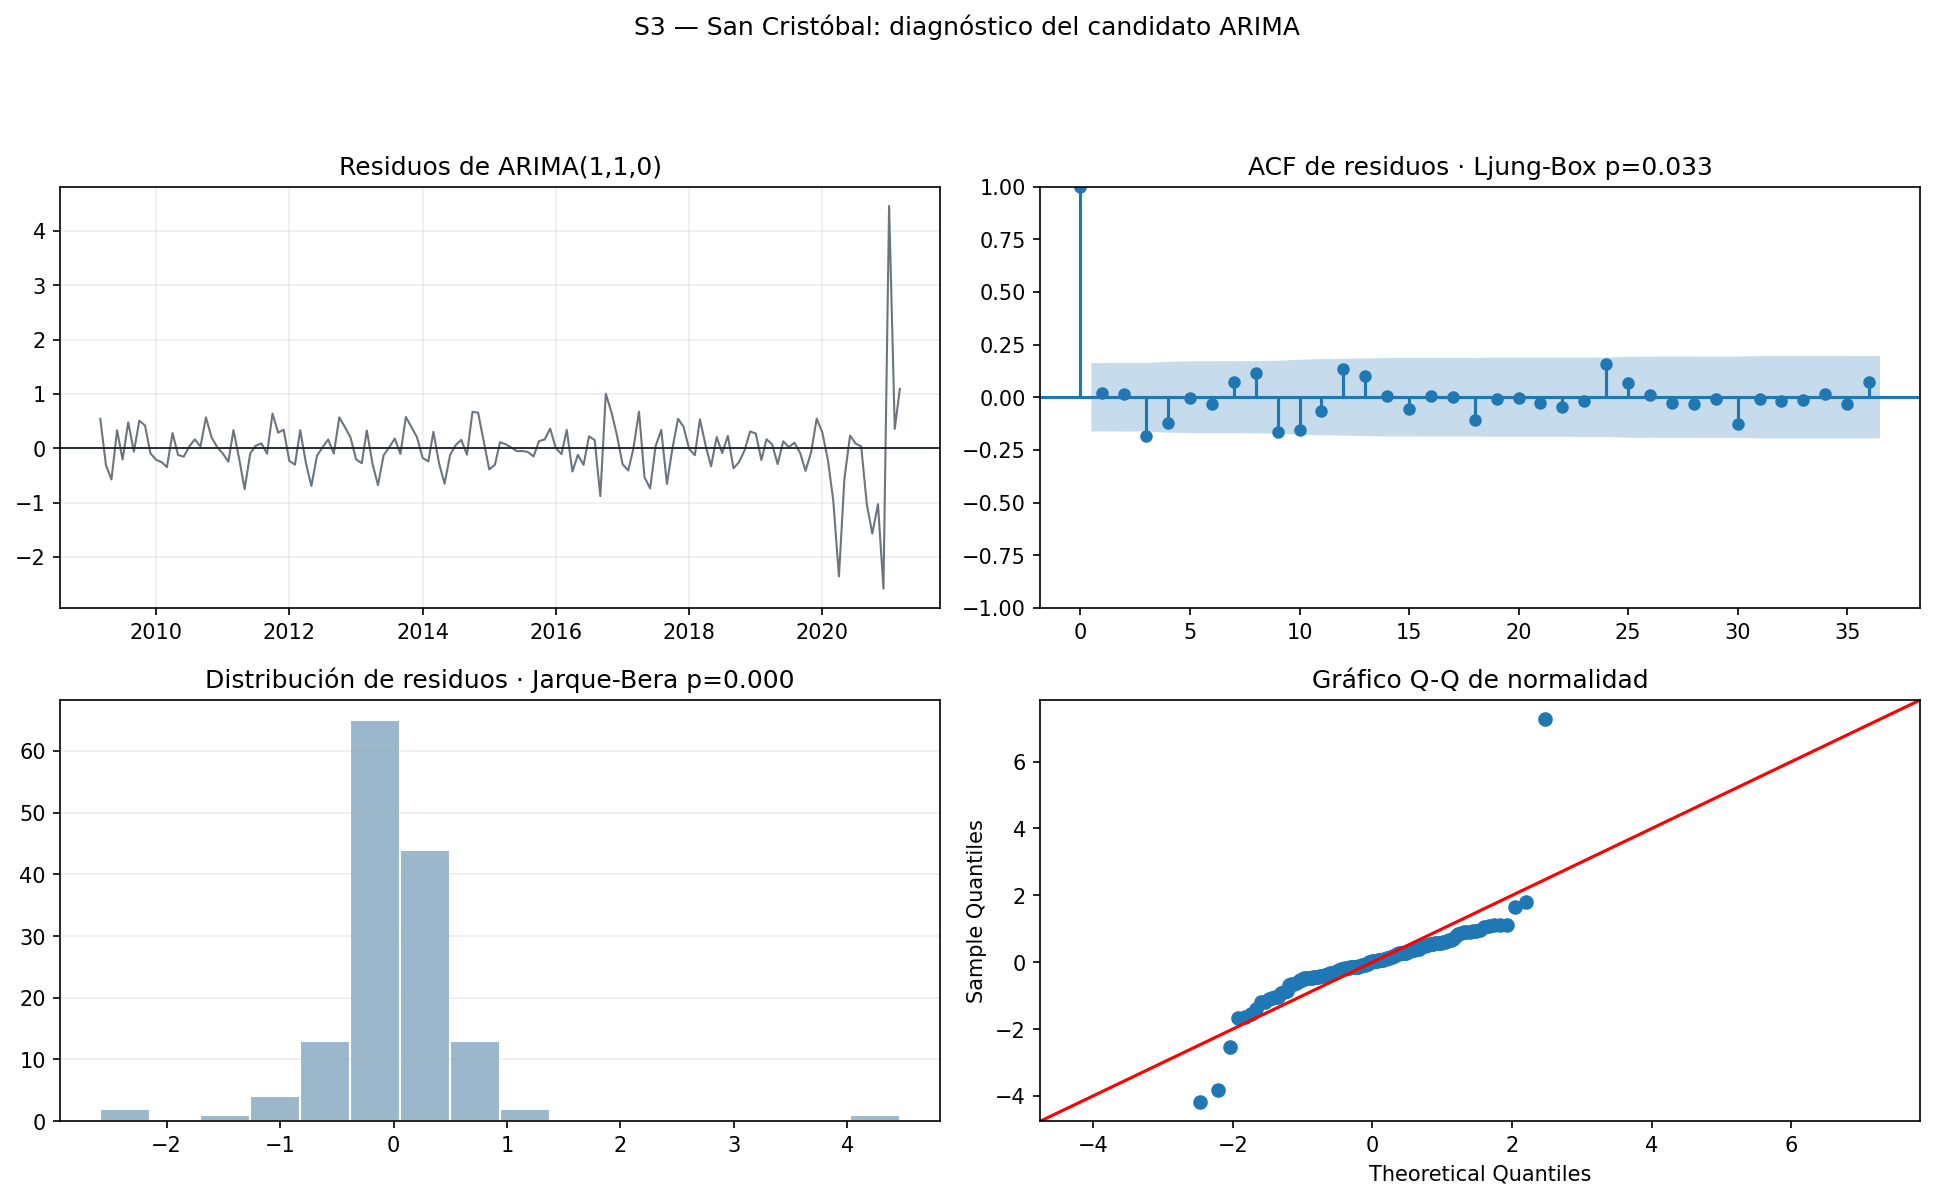

In [10]:
display(
    metricas.loc[
        metricas["serie"] == "S3_san_cristobal",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s3_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s3_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s3_residuos.png")))

Prophet obtiene el menor RMSE de S3 (10,437). ARIMA(1,1,0), el ARIMA con
menor error, no deja residuos de ruido blanco (`p_Ljung-Box=0.033`) ni
normales (`p_Jarque-Bera<0.001`).

## Comparación estadística de Fronteras

La evidencia usa la misma escala y período para las tres series:

- Fuerza estacional sobre la descomposición aditiva del entrenamiento.
- Pendiente de tendencia y CAGR entre 2009 y 2019.
- Coeficiente de variación y desviación de log-diferencias prepandemia.
- Caída anual 2020 vs 2019 y recuperación respecto al promedio de 2019.

In [11]:
columnas = [
    "frontera", "fuerza_estacional", "fuerza_tendencia",
    "pendiente_tendencia_relativa_pct_mes", "cagr_2009_2019_pct",
    "coeficiente_variacion_2009_2019",
    "desviacion_log_diferencias_2009_2019",
    "caida_2020_vs_2019_pct",
    "fecha_primera_recuperacion_mensual",
    "meses_primera_recuperacion_mensual",
    "fecha_recuperacion_sostenida_media_movil_2019",
]
display(comparativo[columnas].round(4))

,frontera,fuerza_estacional,fuerza_tendencia,pendiente_tendencia_relativa_pct_mes,cagr_2009_2019_pct,coeficiente_variacion_2009_2019,desviacion_log_diferencias_2009_2019,caida_2020_vs_2019_pct,fecha_primera_recuperacion_mensual,meses_primera_recuperacion_mensual,fecha_recuperacion_sostenida_media_movil_2019
0,La Aurora,0.5593,0.8114,0.4118,4.7445,0.2168,0.1708,72.8118,2022-07-01,28,NaT
1,Valle Nuevo,0.3111,0.7656,0.7784,9.6913,0.3979,0.3691,80.7194,2022-12-01,33,NaT
2,San Cristóbal,0.3987,0.7067,0.9841,12.9467,0.5222,0.3478,72.5660,2022-06-01,27,NaT


### Respuestas

1. **Mayor estacionalidad: La Aurora** (0.559).
2. **Mayor crecimiento relativo: San Cristóbal**, con CAGR 12.95% y pendiente
   relativa mensual 0.984%.
3. **Mayor volatilidad mes a mes: Valle Nuevo**, según la desviación de
   log-diferencias (0.369). San Cristóbal tiene el mayor coeficiente de
   variación (0.522), por lo que es el más disperso respecto a su propio nivel.
4. **Más afectada por la pandemia: Valle Nuevo**, con caída de 80.72% y el
   retorno mensual más tardío al promedio de 2019, en diciembre de 2022.
   Ninguna frontera ha sostenido todavía una media móvil de 12 meses al nivel
   promedio de 2019 hasta junio de 2026.

## Conclusión del Bloque B

Las tres series de Fronteras quedaron analizadas con el mismo contrato
metodológico y la misma tabla de resultados. La Aurora es la más estacional,
San Cristóbal crecía más rápido antes de la pandemia y Valle Nuevo muestra la
mayor volatilidad mensual y el mayor impacto pandémico. Ningún algoritmo gana
en todos los puntos de entrada: ARIMA fue mejor en S1 y Prophet en S2 y S3.